# IMDB Multimodal Movie Genre Classification
**Northwestern Text Analytics — Final Project**

**Dataset:** [IMDB Multimodal Vision and NLP Genre Classification](https://www.kaggle.com/datasets/zulkarnainsaurav/imdb-multimodal-vision-and-nlp-genre-classification)  
**Genres:** Action · Comedy · Horror · Romance

---
### Notebook Outline
1. Setup & Configuration
2. Data Loading & Column Analysis
3. Text Cleaning — Before/After Examples
4. Summarization Tool
5. Model Training (Naive Bayes · Logistic Regression · Linear SVM · LSTM)
6. Model Evaluation — Accuracy & Confusion Matrices
7. LSTM Training Curves & Architecture
8. Word Importance & Word Clouds (all 4 models)
9. Additional NLP Techniques — t-SNE, LDA, Sentiment Analysis
10. Model Disagreement Analysis
11. Interactive Genre Predictor

## 1. Setup & Configuration

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import json
import re
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Add project root to path ──────────────────────────────────────────────────
ROOT = Path('..').resolve()   # notebook lives in notebooks/, src/ is one level up
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# ── Third-party ───────────────────────────────────────────────────────────────
import joblib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_style('whitegrid')

# ── Project configuration ─────────────────────────────────────────────────────
DATA_PATH    = ROOT / 'data' / 'movies.csv'   # ← update this path if needed
TEXT_COLUMN  = 'Plot'                          # ← update to match your CSV column name
LABEL_COLUMN = 'Genre'                         # ← update to match your CSV column name
OUTPUT_DIR   = ROOT / 'outputs'
MODEL_DIR    = ROOT / 'models'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(exist_ok=True)
(OUTPUT_DIR / 'tables').mkdir(exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('Project root :', ROOT)
print('Data file    :', DATA_PATH)
print('Text column  :', TEXT_COLUMN)
print('Label column :', LABEL_COLUMN)

Project root : /Users/wuyusen/Documents/Northwestern MLDS/414 NLP/Homework/Project/nlp-imdb-multimodal-genre-classification
Data file    : /Users/wuyusen/Documents/Northwestern MLDS/414 NLP/Homework/Project/nlp-imdb-multimodal-genre-classification/data/movies.csv
Text column  : Plot
Label column : Genre


## 1.5 Download Dataset (if needed)

The notebook expects a CSV at `DATA_PATH` (default: `data/movies.csv`) with at least the
`Plot` and `Genre` columns. The dataset is hosted on Kaggle:

> [`zulkarnainsaurav/imdb-multimodal-vision-and-nlp-genre-classification`](https://www.kaggle.com/datasets/zulkarnainsaurav/imdb-multimodal-vision-and-nlp-genre-classification)

This cell tries to fetch it automatically. If you've already downloaded the file, just place
it at the path above and this cell will short-circuit. If automatic download fails (no Kaggle
credentials, no internet, etc.) the cell prints the manual steps.

**One-time setup for automatic download**:

```bash
pip install kagglehub               # in the venv
# Go to https://www.kaggle.com/settings → "Create New Token" → save as ~/.kaggle/kaggle.json
chmod 600 ~/.kaggle/kaggle.json
```


In [2]:
# ── 1.5 Auto-download the IMDB multimodal dataset ────────────────────────────
import shutil

KAGGLE_SLUG = 'zulkarnainsaurav/imdb-multimodal-vision-and-nlp-genre-classification'
DATA_DIR = DATA_PATH.parent
DATA_DIR.mkdir(parents=True, exist_ok=True)
POSTERS_DIR = ROOT / 'data' / 'posters'   # 💡 src/eda_images.py looks here by default.

# Mapping from possible CSV column names (lowercased) → canonical names expected
# by Section 1's TEXT_COLUMN / LABEL_COLUMN. We rename in-place so the rest of
# the notebook sees a consistent schema regardless of which version of the
# Kaggle dataset is downloaded.
CANONICAL_TEXT_NAMES  = {'plot', 'summary', 'description'}
CANONICAL_LABEL_NAMES = {'genre', 'genres'}


def _adopt_first_matching_csv(search_root: Path, target: Path) -> Path | None:
    """Find a CSV in `search_root` whose columns include text+label, copy to target."""
    for csv in sorted(search_root.rglob('*.csv')):
        try:
            head = pd.read_csv(csv, nrows=2)
        except Exception:
            continue
        cols = {c.lower() for c in head.columns}
        if (cols & CANONICAL_TEXT_NAMES) and (cols & CANONICAL_LABEL_NAMES):
            shutil.copy(csv, target)
            return csv
    return None


def _adopt_poster_folder(search_root: Path, target: Path) -> Path | None:
    """Find a `*posters*` directory with genre subfolders and link/copy to target."""
    for d in search_root.rglob('*'):
        if not d.is_dir() or 'poster' not in d.name.lower():
            continue
        # Must have at least one genre-like subfolder containing images.
        for child in d.iterdir():
            if child.is_dir() and any(f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
                                       for f in child.iterdir()):
                # Prefer a symlink — cheap and keeps a single source of truth.
                if target.exists() or target.is_symlink():
                    return d  # already wired up
                try:
                    target.symlink_to(d.resolve())
                except OSError:
                    # ⚠ Symlinks may fail on Windows or restricted filesystems → copy fallback.
                    shutil.copytree(d, target)
                return d
    return None


def _normalize_csv_columns(csv_path: Path) -> None:
    """Rename text/label columns in the CSV to match the notebook's TEXT_COLUMN/LABEL_COLUMN."""
    df = pd.read_csv(csv_path)
    renames = {}
    for c in df.columns:
        if c == TEXT_COLUMN or c == LABEL_COLUMN:
            continue
        if c.lower() in CANONICAL_TEXT_NAMES:
            renames[c] = TEXT_COLUMN
        elif c.lower() in CANONICAL_LABEL_NAMES:
            renames[c] = LABEL_COLUMN
    if renames:
        df.rename(columns=renames, inplace=True)
    # 💡 Also normalise label *values* to Title Case so they match the poster
    # folder names (Action/Comedy/Horror/Romance) used elsewhere in the project.
    if LABEL_COLUMN in df.columns:
        df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str).str.strip().str.title()
    df.to_csv(csv_path, index=False)
    if renames:
        print(f'  ✓ renamed columns {renames} → schema now matches cell 2.')


# ──────────────────────────────────────────────────────────────────────────────
# Step 1: CSV (movies.csv)
# ──────────────────────────────────────────────────────────────────────────────
if DATA_PATH.exists():
    print(f'✓ {DATA_PATH} already exists '
          f'({DATA_PATH.stat().st_size / 1e6:.1f} MB) — skipping CSV download.')
else:
    print(f'CSV missing → fetching from Kaggle ({KAGGLE_SLUG})…')
    downloaded = False
    try:
        import kagglehub  # type: ignore
        cache_path = Path(kagglehub.dataset_download(KAGGLE_SLUG))
        print(f'  kagglehub cached files at: {cache_path}')
        adopted = _adopt_first_matching_csv(cache_path, DATA_PATH)
        # Also wire up the poster folder while we have the cache path handy.
        poster_src = _adopt_poster_folder(cache_path, POSTERS_DIR)
        if poster_src is not None:
            print(f'  ✓ posters available at {POSTERS_DIR} (linked to {poster_src})')
        if adopted is not None:
            downloaded = True
            print(f'  ✓ adopted {adopted.name} → {DATA_PATH}')
    except ImportError:
        print('  kagglehub not installed. Run: pip install "kagglehub<1.0"')
    except Exception as exc:
        print(f'  kagglehub failed: {exc}')

    if not downloaded:
        print()
        print('=' * 70)
        print('AUTOMATIC DOWNLOAD FAILED — please do one of the following:')
        print('=' * 70)
        print(f'1. Install kagglehub + set up Kaggle credentials, then re-run:')
        print(f'     pip install "kagglehub<1.0"')
        print(f'     # then create a token at https://www.kaggle.com/settings')
        print(f'     # and save it to ~/.kaggle/kaggle.json (chmod 600).')
        print()
        print(f'2. OR download manually from:')
        print(f'     https://www.kaggle.com/datasets/{KAGGLE_SLUG}')
        print(f'   unzip it, and place the CSV at: {DATA_PATH}')
        raise FileNotFoundError(f'Dataset still missing at {DATA_PATH}')

# Always normalise column names so the rest of the notebook can rely on
# TEXT_COLUMN / LABEL_COLUMN regardless of where the CSV came from.
_normalize_csv_columns(DATA_PATH)

# ──────────────────────────────────────────────────────────────────────────────
# Step 2: posters (best-effort — only matters for the multimodal section)
# ──────────────────────────────────────────────────────────────────────────────
if POSTERS_DIR.exists():
    poster_count = sum(1 for p in POSTERS_DIR.rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})
    print(f'✓ {poster_count} poster images available under {POSTERS_DIR}')
else:
    print(f'(posters not wired up at {POSTERS_DIR} — Section 2.7 will skip; not fatal.)')

assert DATA_PATH.exists(), f'Expected dataset at {DATA_PATH} after this cell.'
print(f'\nDataset ready at {DATA_PATH}')

✓ /Users/wuyusen/Documents/Northwestern MLDS/414 NLP/Homework/Project/nlp-imdb-multimodal-genre-classification/data/movies.csv already exists (2.0 MB) — skipping CSV download.
✓ 1325 poster images available under /Users/wuyusen/Documents/Northwestern MLDS/414 NLP/Homework/Project/nlp-imdb-multimodal-genre-classification/data/posters

Dataset ready at /Users/wuyusen/Documents/Northwestern MLDS/414 NLP/Homework/Project/nlp-imdb-multimodal-genre-classification/data/movies.csv


## 2. Data Loading & Column Analysis

In [3]:
from src.data_processing import load_dataset, basic_profile, add_clean_columns

df_raw = load_dataset(DATA_PATH)
print(f'Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns\n')
df_raw.head(3)

Dataset shape: 1,000 rows × 3 columns



,movie_id,Plot,Genre
0,tt12783454,Elle Evans (Joey King) has finally completed h...,Romance
1,tt1798632,A young girl tries to understand how she myste...,Horror
2,tt9214832,"In 1800s England, a well meaning but selfish y...",Comedy


In [4]:
# ── Column inventory ──────────────────────────────────────────────────────────
col_info = pd.DataFrame({
    'dtype'  : df_raw.dtypes,
    'missing': df_raw.isna().sum(),
    'missing_%': (df_raw.isna().mean() * 100).round(1),
    'unique' : df_raw.nunique(),
    'sample' : df_raw.iloc[0],
})
print('=== Column Summary ===')
display(col_info)

=== Column Summary ===


,dtype,missing,missing_%,unique,sample
movie_id,str,0,0.0,1000,tt12783454
Plot,str,0,0.0,1000,Elle Evans (Joey King) has finally completed h...
Genre,str,0,0.0,4,Romance


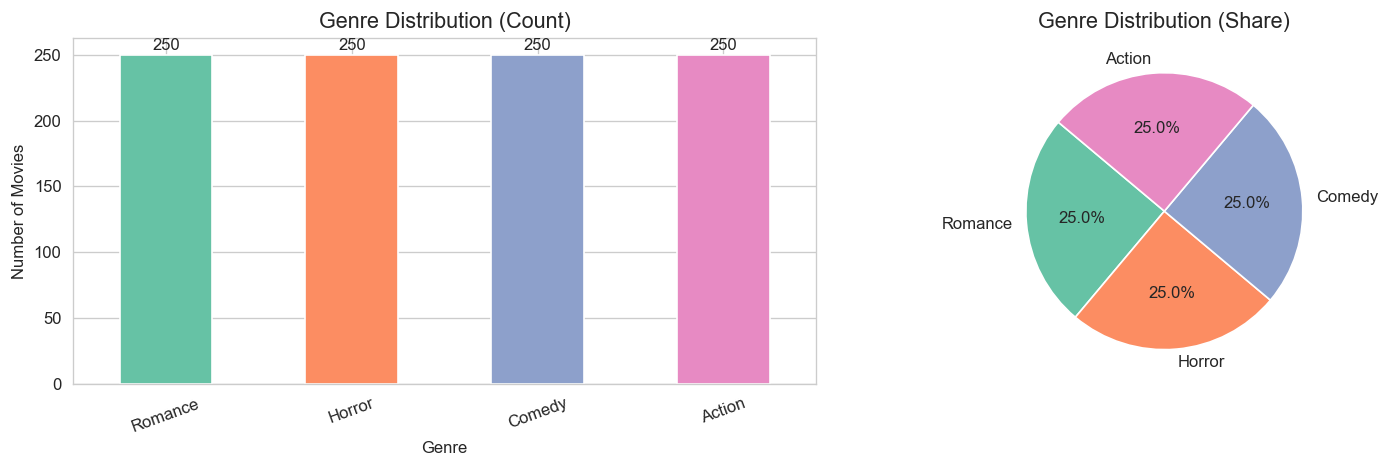

Class balance: {'Romance': 250, 'Horror': 250, 'Comedy': 250, 'Action': 250}


In [5]:
# ── Genre distribution ────────────────────────────────────────────────────────
genre_counts = df_raw[LABEL_COLUMN].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = sns.color_palette('Set2', len(genre_counts))
genre_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Genre Distribution (Count)', fontsize=13)
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Number of Movies')
axes[0].tick_params(axis='x', rotation=20)
for bar, count in zip(axes[0].patches, genre_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(count), ha='center', va='bottom', fontsize=10)

genre_counts.plot(kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%',
                  startangle=140, legend=False)
axes[1].set_title('Genre Distribution (Share)', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'genre_distribution.png', dpi=150)
plt.show()
print('Class balance:', genre_counts.to_dict())

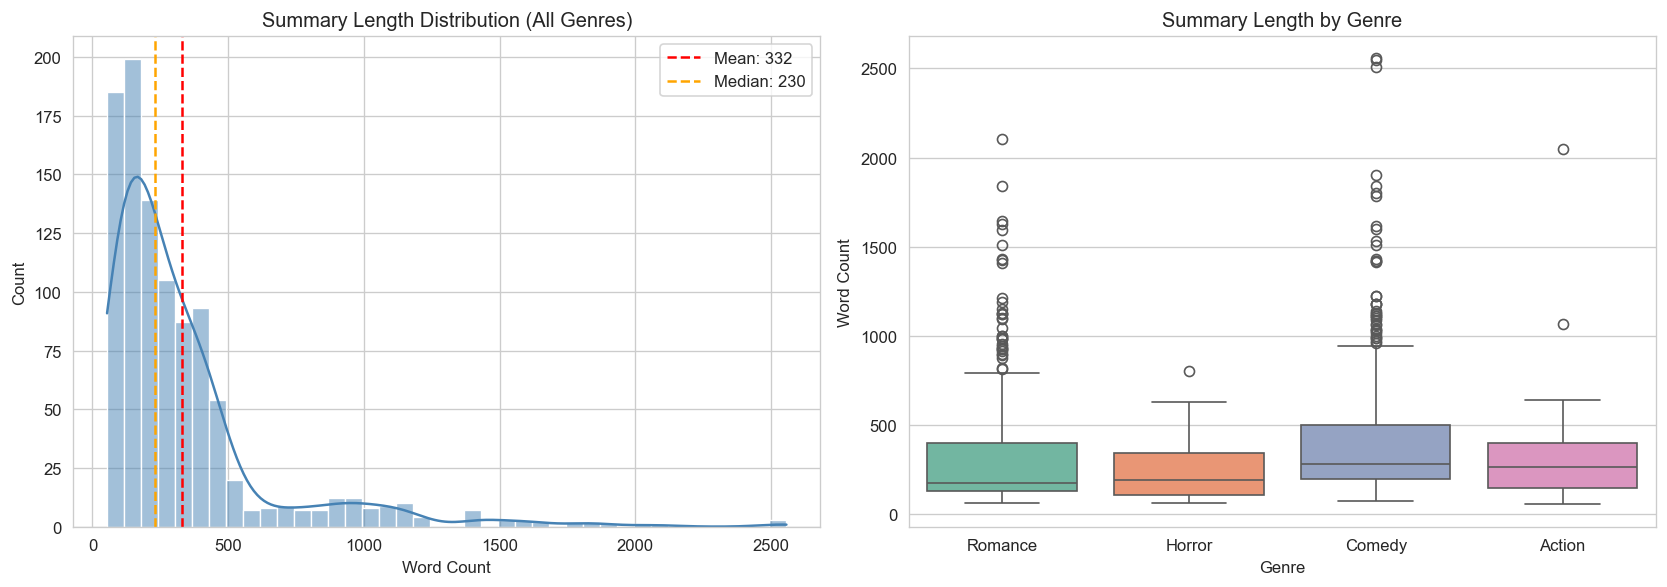

=== Word Count Statistics by Genre ===


,mean,median,min,max,count
Genre,,,,,
Action,280.3,263.5,54,2048,250
Comedy,466.1,281.0,72,2557,250
Horror,230.8,189.5,62,805,250
Romance,350.5,173.0,60,2103,250


In [6]:
# ── Summary length analysis ───────────────────────────────────────────────────
df_raw['word_count'] = df_raw[TEXT_COLUMN].fillna('').str.split().map(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall histogram
sns.histplot(df_raw['word_count'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Summary Length Distribution (All Genres)', fontsize=12)
axes[0].set_xlabel('Word Count')
axes[0].axvline(df_raw['word_count'].mean(), color='red', linestyle='--',
                label=f"Mean: {df_raw['word_count'].mean():.0f}")
axes[0].axvline(df_raw['word_count'].median(), color='orange', linestyle='--',
                label=f"Median: {df_raw['word_count'].median():.0f}")
axes[0].legend()

# By-genre boxplot
order = genre_counts.index.tolist()
sns.boxplot(data=df_raw, x=LABEL_COLUMN, y='word_count', order=order,
            palette='Set2', ax=axes[1])
axes[1].set_title('Summary Length by Genre', fontsize=12)
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'summary_length_distribution.png', dpi=150)
plt.show()

print('=== Word Count Statistics by Genre ===')
display(df_raw.groupby(LABEL_COLUMN)['word_count']
        .agg(['mean','median','min','max','count'])
        .round(1))

In [7]:
# ── Sample records per genre ──────────────────────────────────────────────────
print('=== One sample summary per genre ===')
for genre, group in df_raw.groupby(LABEL_COLUMN):
    sample = group.sample(1, random_state=42).iloc[0]
    print(f"\n{'='*60}")
    print(f"Genre : {genre}")
    print(f"Plot  : {str(sample[TEXT_COLUMN])[:400]}...")

=== One sample summary per genre ===

Genre : Action
Plot  : The Knight Jean de Carrouges must settle the dispute over his wife Marguerite by challenging his squire to a duel to the death. Based on the true story of France's last trial by combat in the Middle Ages. Knight Jean de Carrouges challenges his former friend Jacques Le Gris to a duel after Jean's wife Marguerite accuses Le Gris of rape. Told in multiple "Rashomon-style" points of view. In medieval...

Genre : Comedy
Plot  : The African monarch Akeem learns he has a longlost son in the United States and must return to America to meet this unexpected heir and build a relationship with his son. Three long, prosperous decades after Prince Akeem and Lisa McDowell's opulent wedding in Coming to America , King Jaffe Joffer and Semmi, sensing that trouble is brewing in the African kingdom of Zamunda, drop a bombshell. As a r...

Genre : Horror
Plot  : A notorious criminal must break an evil curse in order to rescue an abducted girl w

## 2.1 Data Quality Report

Before diving deeper, scan the dataset for systemic issues — duplicates, HTML residue,
non-ASCII rows, very-short summaries. Each row in the report is a category and a count;
if a count is non-zero you may want to drop / clean those rows before training.


In [8]:
# 💡 Idempotent setup — these EDA cells live BEFORE the cleaning pipeline cell
# (Section 3), so `df` (the enriched DataFrame with text_clean_* columns) might
# not exist yet if you're running cells top-to-bottom for the first time.
# This block creates `df` from `df_raw` if needed; it's a no-op otherwise.
if 'df' not in globals() or 'text_clean_classical' not in df.columns:
    from src.data_processing import add_clean_columns
    df = add_clean_columns(df_raw, TEXT_COLUMN)

from src.eda_advanced import duplicate_and_quality_report, length_outliers

quality = duplicate_and_quality_report(df, TEXT_COLUMN, LABEL_COLUMN, OUTPUT_DIR)
display(quality)

outliers = length_outliers(df, TEXT_COLUMN, LABEL_COLUMN, OUTPUT_DIR, z_thresh=3.0)
print(f'{len(outliers)} length outliers (|z| >= 3) flagged for review.')
display(outliers.head(10))

,category,count
0,rows_total,1000
1,exact_duplicates,0
2,normalised_text_duplicates,0
3,html_residue,0
4,non_ascii_heavy,0
5,very_short_lt5_tokens,0
6,missing_text,0
7,missing_label,0


14 length outliers (|z| >= 3) flagged for review.


,Genre,Plot,word_count,z,genre_mean,genre_std
0,Action,"In 1999 in London, a teenage Zoya (Katrina Kai...",1068,4.333874,280.264,181.762573
1,Action,"After splitting with the Joker, Harley Quinn j...",2048,9.725523,280.264,181.762573
2,Comedy,The untold story of one twelve-year-old's drea...,2546,4.576951,466.124,454.423962
3,Comedy,Drea and Eleanor agree to go after one another...,2557,4.601157,466.124,454.423962
4,Comedy,Once told they'd save the universe during a ti...,1839,3.021135,466.124,454.423962
5,Comedy,women find themselves dealing with a mystery ...,1904,3.164173,466.124,454.423962
6,Comedy,"While at the royal ball with Cinderella, Littl...",2511,4.499930,466.124,454.423962
7,Horror,Keira Woods' daughter mysteriously vanishes in...,805,4.025817,230.768,142.637386
8,Romance,Elle Evans (Joey King) has finally completed h...,2103,4.654993,350.464,376.485226
9,Romance,Majnu Stuck in a loveless marriage with Babloo...,1842,3.961738,350.464,376.485226


## 2.2 N-gram & Distinctive-Term Analysis

What does each genre "sound like"? Two complementary views:

- **Top n-grams per genre** — raw bigram / trigram frequencies after cleaning.
- **Distinctive terms** — terms whose mean TF-IDF *inside* the genre is much higher than *outside* it.
  This is the headline EDA insight: if Horror's top distinctive terms are not "blood / kill / haunt",
  the cleaning pipeline is probably stripping too much signal.


In [9]:
from src.eda_advanced import ngram_frequency, tfidf_top_terms_per_genre

ngrams = ngram_frequency(df, 'text_clean_classical', LABEL_COLUMN, OUTPUT_DIR, n_values=(2, 3), top_k=15)
display(ngrams[ngrams['scope'] == 'overall'].head(15))

distinctive = tfidf_top_terms_per_genre(df, 'text_clean_classical', LABEL_COLUMN, OUTPUT_DIR, top_k=15)
display(distinctive.pivot_table(index='rank', columns='genre', values='term', aggfunc='first'))

,ngram_length,scope,ngram,count
0,2,overall,high school,99
1,2,overall,best friend,90
2,2,overall,best friends,41
3,2,overall,york city,39
4,2,overall,small town,38
5,2,overall,los angeles,36
6,2,overall,lara jean,36
7,2,overall,police officer,35
8,2,overall,returns home,34
9,2,overall,they re,34


genre,Action,Comedy,Horror,Romance
rank,,,,
1,mission,friends,horror,love
2,team,school,dark,relationship
3,dangerous,star,demon,marriage
4,war,high,terrifying,meets
5,battle,high school,house,meet
6,criminal,best,supernatural,romance
7,assassin,party,strange,affair
8,forces,big,mysterious,feelings
9,army,kids,evil,she


## 2.3 Vocabulary Structure & OOV Curve

- **Vocabulary uniqueness**: how much of each genre's vocab is genre-exclusive vs. shared.
  A pairwise Jaccard heatmap visualises which genres overlap most.
- **OOV curve**: at the tokenizer cap (`LSTMConfig.max_words = 15000`), what fraction of tokens
  fall out of vocabulary? If the curve hasn't flattened by 15000, raising `max_words` may help the LSTM.


In [10]:
from src.eda_advanced import vocabulary_uniqueness, oov_curve

vocab = vocabulary_uniqueness(df, 'text_clean_classical', LABEL_COLUMN, OUTPUT_DIR)
display(vocab[['genre', 'vocab_size', 'exclusive_count', 'exclusive_pct']])

oov = oov_curve(df, TEXT_COLUMN, LABEL_COLUMN, OUTPUT_DIR)
display(oov)

,genre,vocab_size,exclusive_count,exclusive_pct
0,Action,5134,1761,34.300740
1,Comedy,6772,2553,37.699350
2,Horror,4138,1127,27.235379
3,Romance,5260,1600,30.418251


,vocab_size,oov_token_rate
0,1000,0.344448
1,5000,0.179714
2,10000,0.115370
3,15000,0.080436
4,30000,0.028062


## 2.4 Readability & Style

If `textstat` is installed, this computes Flesch reading ease, Flesch-Kincaid grade,
sentence counts, and type-token ratio per genre. The cell skips gracefully if not installed.


In [11]:
from src.eda_advanced import readability_metrics

readability = readability_metrics(df, TEXT_COLUMN, LABEL_COLUMN, OUTPUT_DIR)
if readability.empty:
    print('Install `textstat` to enable readability analysis: pip install textstat')
else:
    display(readability)

,genre,idx_mean,idx_median,idx_std,flesch_reading_ease_mean,flesch_reading_ease_median,flesch_reading_ease_std,flesch_kincaid_grade_mean,flesch_kincaid_grade_median,flesch_kincaid_grade_std,sentence_count_mean,sentence_count_median,sentence_count_std,avg_sentence_length_mean,avg_sentence_length_median,avg_sentence_length_std,ttr_mean,ttr_median,ttr_std
0,Action,500.540,483.5,291.117775,52.204134,52.969230,10.653184,11.837352,11.406235,3.018161,12.796,12.0,9.420263,23.586134,22.732143,7.174146,0.612174,0.602330,0.085188
1,Comedy,518.984,514.5,287.539876,54.624396,55.444494,10.906464,11.357029,11.102378,2.679624,21.700,12.0,22.605442,23.011541,22.291667,5.795560,0.587722,0.603471,0.106639
2,Horror,486.972,490.5,286.140561,54.017007,55.491056,11.091844,11.176526,10.872220,2.632698,11.272,8.0,7.731826,21.943941,21.000000,5.566309,0.632060,0.618379,0.085679
3,Romance,491.504,511.0,291.140028,55.605238,56.337588,11.600109,10.781877,10.682923,2.720235,18.044,9.0,21.099926,21.247065,20.081250,5.564375,0.610787,0.630984,0.109720


## 2.5 Class Overlap in Text Space

Cosine similarity between per-genre TF-IDF centroids — a quick way to **predict the confusion
matrix before training**. Pairs with high similarity here usually dominate the off-diagonal of
the eventual confusion matrix; pairs with low similarity should be cleanly separable.


In [12]:
from src.eda_advanced import class_overlap_text

overlap = class_overlap_text(df, 'text_clean_classical', LABEL_COLUMN, OUTPUT_DIR)
display(overlap.round(3))

,Action,Comedy,Horror,Romance
Action,1.000,0.642,0.609,0.550
Comedy,0.642,1.000,0.681,0.761
Horror,0.609,0.681,1.000,0.600
Romance,0.550,0.761,0.600,1.000


## 2.6 Cleaning-Pipeline Impact

How much does each cleaning pipeline reshape the data? Reports vocab size, total tokens,
and the fraction of tokens dropped vs. the raw text. Use this to defend the choice of
classical (stopword-removed) vs. neural (light) cleaning for downstream models.


In [13]:
from src.eda_advanced import cleaning_pipeline_impact

impact = cleaning_pipeline_impact(
    df, TEXT_COLUMN, 'text_clean_classical', 'text_clean_neural', LABEL_COLUMN, OUTPUT_DIR,
)
display(impact)

,pipeline,vocab_size,total_tokens,pct_tokens_dropped_vs_raw
0,raw,39314,331905,0.000000
1,classical,24272,164257,50.510839
2,neural,24608,335778,-1.166900


## 2.7 Poster EDA — Multimodal Bonus

The text models train on plot summaries, but each movie also has a poster. This cell
runs a lightweight visual EDA on the poster set if available.

**Sources** (first-found wins):
1. `data/posters/<genre>/*.jpg` (folder-per-class layout)
2. A CSV with `poster_path` and `genre` columns
3. TMDB API fetch (requires `TMDB_API_KEY` env var)

If none of these are available, the cell prints what to set up and moves on.


In [14]:
from src.eda_images import build_catalog, run_full_image_eda

poster_catalog = build_catalog(posters_dir=ROOT / 'data' / 'posters')  # default: data/posters/<genre>/, falls back gracefully
if poster_catalog.empty:
    print('No poster data — skipping image EDA. See message above for setup options.')
else:
    print(f'Loaded {len(poster_catalog)} posters across {poster_catalog["genre"].nunique()} genres.')
    artifacts = run_full_image_eda(poster_catalog, OUTPUT_DIR)
    display(artifacts.get('inventory'))
    display(artifacts.get('palette'))

[eda_images] found 1325 local posters under /Users/wuyusen/Documents/Northwestern MLDS/414 NLP/Homework/Project/nlp-imdb-multimodal-genre-classification/data/posters.
Loaded 1325 posters across 4 genres.


,genre,count,missing,broken
0,Action,337,0,0
1,Comedy,321,0,0
2,Horror,398,0,0
3,Romance,269,0,0


,genre,rank,r,g,b,hex,share
0,Action,1,22,22,26,#16161a,0.381917
1,Action,2,89,74,70,#594a46,0.250083
2,Action,3,239,237,228,#efede4,0.136750
3,Action,4,136,152,154,#88989a,0.121833
4,Action,5,205,155,90,#cd9b5a,0.109417
5,Comedy,1,34,31,41,#221f29,0.268417
6,Comedy,2,116,84,67,#745443,0.235333
7,Comedy,3,195,151,116,#c39774,0.221833
8,Comedy,4,227,230,228,#e3e6e4,0.152417
9,Comedy,5,66,145,179,#4291b3,0.122000


## 3. Text Cleaning — Before / After Examples

We use **two cleaning pipelines**:
- **Classical pipeline** (`text_clean_classical`): lowercase, remove HTML/punctuation/URLs, remove stopwords — maximises discriminative signal for bag-of-words models.
- **Neural pipeline** (`text_clean_neural`): lighter cleaning without stopword removal — preserves word order and sentence structure for the LSTM.

In [15]:
from src.data_processing import clean_text, add_clean_columns
from src.config import TextCleaningConfig

df = add_clean_columns(df_raw, TEXT_COLUMN)

print('Cleaning comparison on 3 sample summaries:\n')
samples = df.sample(3, random_state=7)
for i, (_, row) in enumerate(samples.iterrows(), 1):
    original   = str(row[TEXT_COLUMN])[:350]
    classical  = str(row['text_clean_classical'])[:350]
    neural     = str(row['text_clean_neural'])[:350]
    print(f'--- Sample {i} (Genre: {row[LABEL_COLUMN]}) ---')
    print(f'ORIGINAL  : {original}')
    print(f'CLASSICAL : {classical}')
    print(f'NEURAL    : {neural}\n')

Cleaning comparison on 3 sample summaries:

--- Sample 1 (Genre: Horror) ---
ORIGINAL  : Emma must uncover the dark secret behind a cursed radio to survive and protect her family. After her father ends up in the hospital, Emma flies back from New York to her hometown in Italy and stays at her parents' home. All alone in the house, she faces an evil entity that is connected to a cursed radio. Emma will have to unveil the dark secret beh
CLASSICAL : emma uncover dark secret cursed radio survive protect family father ends hospital emma flies york hometown italy stays parents' home house faces evil entity connected cursed radio emma unveil dark secret radio survive protect ones loves
NEURAL    : emma must uncover the dark secret behind a cursed radio to survive and protect her family after her father ends up in the hospital emma flies back from new york to her hometown in italy and stays at her parents' home all alone in the house she faces an evil entity that is connected to a cursed radi

In [16]:
# ── Vocabulary size before vs. after cleaning ─────────────────────────────────
vocab_raw       = set(' '.join(df[TEXT_COLUMN].fillna('')).lower().split())
vocab_classical = set(' '.join(df['text_clean_classical']).split())
vocab_neural    = set(' '.join(df['text_clean_neural']).split())

vocab_df = pd.DataFrame({
    'Pipeline':    ['Raw text', 'Classical (stopwords removed)', 'Neural (light clean)'],
    'Vocab size':  [len(vocab_raw), len(vocab_classical), len(vocab_neural)],
    'Reduction %': [0,
                    round((1 - len(vocab_classical)/len(vocab_raw))*100, 1),
                    round((1 - len(vocab_neural)/len(vocab_raw))*100, 1)]
})
display(vocab_df)

,Pipeline,Vocab size,Reduction %
0,Raw text,39314,0.0
1,Classical (stopwords removed),24272,38.3
2,Neural (light clean),24608,37.4


## 4. Summarization Tool

We implement two summarizers:
1. **Extractive** (TF/frequency-based) — fast, always available, good for short demos.
2. **Transformer** (HuggingFace `sshleifer/distilbart-cnn-12-6`) — abstractive, requires `transformers` installed.

In [17]:
from src.summarize import extractive_summary, transformer_summary

# Pick one movie per genre
print('=== Extractive Summaries ===')
for genre, group in df.groupby(LABEL_COLUMN):
    row = group.sample(1, random_state=42).iloc[0]
    original = str(row[TEXT_COLUMN])
    summary  = extractive_summary(original, max_sentences=3)
    print(f'\n[{genre.upper()}]')
    print(f'  Original  ({len(original.split()):>4} words): {original[:200]}...')
    print(f'  Extracted ({len(summary.split()):>4} words): {summary}')

=== Extractive Summaries ===

[ACTION]
  Original  ( 424 words): The Knight Jean de Carrouges must settle the dispute over his wife Marguerite by challenging his squire to a duel to the death. Based on the true story of France's last trial by combat in the Middle A...
  Extracted (  62 words): The Knight Jean de Carrouges must settle the dispute over his wife Marguerite by challenging his squire to a duel to the death. The truth according to Jean, the truth according to Jacques and the truth according to Lady Marguerite. Knowing that Pierre protects Jacques, Jean resolves to challenge him to a duel to the death, a request which Charles VI grants.

[COMEDY]
  Original  ( 789 words): The African monarch Akeem learns he has a longlost son in the United States and must return to America to meet this unexpected heir and build a relationship with his son. Three long, prosperous decade...
  Extracted ( 189 words): When General Izzi learns of this, he drops by to introduce his daughter Bopoto 

In [18]:
# ── Optional: Transformer-based abstractive summarization ─────────────────────
# Uncomment the block below if 'transformers' is installed and you have GPU/time.

# sample_text = df[df[LABEL_COLUMN] == 'Horror'].sample(1, random_state=1)[TEXT_COLUMN].values[0]
# print('Original:', sample_text[:400], '...')
# try:
#     ab_summary = transformer_summary(sample_text)
#     print('\nTransformer summary:', ab_summary)
# except RuntimeError as e:
#     print('Transformer unavailable:', e)

In [19]:
# ── Save summarization examples to CSV ───────────────────────────────────────
summary_rows = []
for genre, group in df.groupby(LABEL_COLUMN):
    for _, row in group.sample(min(3, len(group)), random_state=42).iterrows():
        orig = str(row[TEXT_COLUMN])
        summary_rows.append({
            'genre': genre,
            'original_words': len(orig.split()),
            'original': orig[:300],
            'extractive_summary': extractive_summary(orig, max_sentences=2),
        })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_DIR / 'tables' / 'sample_summaries.csv', index=False)
print('Saved sample summaries →', OUTPUT_DIR / 'tables' / 'sample_summaries.csv')
display(summary_df[['genre','original_words','extractive_summary']].head(8))

Saved sample summaries → /Users/wuyusen/Documents/Northwestern MLDS/414 NLP/Homework/Project/nlp-imdb-multimodal-genre-classification/outputs/tables/sample_summaries.csv


,genre,original_words,extractive_summary
0,Action,424,The Knight Jean de Carrouges must settle the d...
1,Action,122,A former Special Forces operative thrust into ...
2,Action,360,"Finally, Lindy is subjected to an experimental..."
3,Comedy,789,"When General Izzi learns of this, he drops by ..."
4,Comedy,99,"Carmen Berzatto, a brilliant young chef from t..."
5,Comedy,417,"As the warm, bright sun refuses to set, and a ..."
6,Horror,91,The Governor offers the prisoner his freedom i...
7,Horror,83,A hiker finds shelter in a mountain lodge inha...


## 5. Model Training

We train four classifiers:

| # | Model | Type | Features |
|---|-------|------|----------|
| 1 | Multinomial Naive Bayes | Classical | TF-IDF (1–2 grams) |
| 2 | Logistic Regression | GLM | TF-IDF (1–2 grams) |
| 3 | Linear SVM | Classical | TF-IDF (1–2 grams) |
| 4 | LSTM | TensorFlow / Deep Learning | Tokenized sequences + Embeddings |

> **Training split:** 70% train / 10% validation / 20% test (stratified by genre)

In [20]:
from src.data_processing import stratified_split

train_df, val_df, test_df = stratified_split(df, LABEL_COLUMN)
labels = sorted(df[LABEL_COLUMN].dropna().unique().tolist())

print(f'Train : {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test  : {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)')
print(f'Labels: {labels}')

Train : 700 (70.0%)
Val   : 100 (10.0%)
Test  : 200 (20.0%)
Labels: ['Action', 'Comedy', 'Horror', 'Romance']


In [21]:
# ── 5a. Baseline models (Naive Bayes, Logistic Regression, Linear SVM) ────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from src.evaluate import compute_metrics, save_metrics, save_confusion_matrix

tfidf_kwargs = dict(lowercase=False, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)

baseline_models = {
    'naive_bayes': Pipeline([
        ('tfidf',  TfidfVectorizer(**tfidf_kwargs)),
        ('model',  MultinomialNB()),
    ]),
    'logistic_regression': Pipeline([
        ('tfidf',  TfidfVectorizer(**tfidf_kwargs)),
        ('model',  LogisticRegression(max_iter=2000, class_weight='balanced')),
    ]),
    'linear_svm': Pipeline([
        ('tfidf',  TfidfVectorizer(**tfidf_kwargs)),
        ('model',  LinearSVC()),
    ]),
}

x_train, y_train = train_df['text_clean_classical'], train_df[LABEL_COLUMN]
x_val,   y_val   = val_df['text_clean_classical'],   val_df[LABEL_COLUMN]
x_test,  y_test  = test_df['text_clean_classical'],  test_df[LABEL_COLUMN]

baseline_results = []
prediction_table = test_df[[TEXT_COLUMN, LABEL_COLUMN]].copy()

for name, pipeline in baseline_models.items():
    print(f'Training {name} …', end=' ')
    pipeline.fit(x_train, y_train)
    test_pred  = pipeline.predict(x_test)
    val_pred   = pipeline.predict(x_val)
    metrics    = compute_metrics(y_test, test_pred, labels)
    val_metrics= compute_metrics(y_val,  val_pred,  labels)
    save_metrics(metrics, MODEL_DIR / f'{name}_metrics.json')
    joblib.dump(pipeline, MODEL_DIR / f'{name}.joblib')
    prediction_table[f'{name}_prediction'] = test_pred
    baseline_results.append({
        'model': name,
        'accuracy': metrics['accuracy'],
        'macro_f1': metrics['macro_f1'],
        'val_accuracy': val_metrics['accuracy'],
    })
    print(f'done  →  test acc={metrics["accuracy"]:.3f}')

prediction_table.to_csv(OUTPUT_DIR / 'tables' / 'baseline_predictions.csv', index=False)
print('\nBaseline models saved.')

Training naive_bayes … done  →  test acc=0.750
Training logistic_regression … done  →  test acc=0.765
Training linear_svm … done  →  test acc=0.740

Baseline models saved.


In [22]:
# ── 5b. LSTM model ────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.preprocessing import LabelEncoder
from src.config import LSTMConfig

config = LSTMConfig(epochs=10)

# Tokenize
tokenizer = Tokenizer(num_words=config.max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['text_clean_neural'])

def vectorize(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=config.max_len, padding='post', truncating='post')

x_tr = vectorize(train_df['text_clean_neural'])
x_va = vectorize(val_df['text_clean_neural'])
x_te = vectorize(test_df['text_clean_neural'])

encoder = LabelEncoder()
y_tr = encoder.fit_transform(train_df[LABEL_COLUMN])
y_va = encoder.transform(val_df[LABEL_COLUMN])
y_te = encoder.transform(test_df[LABEL_COLUMN])
label_names = encoder.classes_.tolist()

# Build
lstm_model = Sequential([
    Embedding(config.max_words, config.embedding_dim, input_length=config.max_len),
    LSTM(config.lstm_units, dropout=config.dropout, recurrent_dropout=config.recurrent_dropout),
    Dense(config.dense_units, activation='relu'),
    Dropout(config.dropout),
    Dense(len(label_names), activation='softmax'),
])
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
# ── Plot model architecture ───────────────────────────────────────────────────
# ⚠ Keras 3 (TF 2.16+) changed two things this cell used to rely on:
#   1. `plot_model` requires the model to be BUILT (have known shapes).
#      Sequential models are only built lazily on first call, so we
#      build explicitly with the expected input shape.
#   2. `layer.output_shape` was removed. Use `layer.output.shape` (only
#      valid after build), or just lean on `model.summary()` as fallback.
if not lstm_model.built:
    lstm_model.build(input_shape=(None, config.max_len))

try:
    arch_path = str(OUTPUT_DIR / 'figures' / 'lstm_architecture.png')
    tf.keras.utils.plot_model(
        lstm_model,
        to_file=arch_path,
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=150,
    )
    from IPython.display import Image
    display(Image(arch_path))
except Exception as e:
    # 💡 plot_model needs pydot + graphviz on the system. If they're missing,
    # `model.summary()` shows the same shape info in plain text — no extra deps.
    print(f'plot_model unavailable ({e}). Falling back to text summary:')
    print()
    lstm_model.summary()

You must install pydot (`pip install pydot`) for `plot_model` to work.


FileNotFoundError: No such file or directory: '/Users/wuyusen/Documents/Northwestern MLDS/414 NLP/Homework/Project/nlp-imdb-multimodal-genre-classification/outputs/figures/lstm_architecture.png'

FileNotFoundError: No such file or directory: '/Users/wuyusen/Documents/Northwestern MLDS/414 NLP/Homework/Project/nlp-imdb-multimodal-genre-classification/outputs/figures/lstm_architecture.png'

<IPython.core.display.Image object>

In [24]:
# ── Train LSTM ────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history = lstm_model.fit(
    x_tr, y_tr,
    validation_data=(x_va, y_va),
    epochs=config.epochs,
    batch_size=config.batch_size,
    callbacks=[early_stop],
    verbose=1,
)

# Save model + tokenizer + metadata
lstm_model.save(MODEL_DIR / 'lstm_text_classifier.keras')
(MODEL_DIR / 'lstm_tokenizer.json').write_text(tokenizer.to_json())
(MODEL_DIR / 'lstm_label_classes.json').write_text(json.dumps(label_names, indent=2))
(MODEL_DIR / 'lstm_config.json').write_text(json.dumps(config.__dict__, indent=2))
print('LSTM saved.')

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.2900 - loss: 1.3847 - val_accuracy: 0.2700 - val_loss: 1.3702
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.3186 - loss: 1.3677 - val_accuracy: 0.2700 - val_loss: 1.3677
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.3486 - loss: 1.3366 - val_accuracy: 0.3200 - val_loss: 1.3648
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.4071 - loss: 1.2929 - val_accuracy: 0.2600 - val_loss: 1.3624
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5371 - loss: 1.2033 - val_accuracy: 0.2600 - val_loss: 1.3842
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5414 - loss: 1.0529 - val_accuracy: 0.2700 - val_loss: 1.3728
LSTM saved.


## 6. Model Evaluation — Accuracy & Confusion Matrices

In [25]:
# ── LSTM predictions ──────────────────────────────────────────────────────────
lstm_probs    = lstm_model.predict(x_te, verbose=0)
lstm_pred_ids = np.argmax(lstm_probs, axis=1)
lstm_preds    = encoder.inverse_transform(lstm_pred_ids)
y_true_str    = encoder.inverse_transform(y_te)

lstm_metrics = compute_metrics(y_true_str, lstm_preds, label_names)
save_metrics(lstm_metrics, MODEL_DIR / 'lstm_metrics.json')

# Add to prediction table
prediction_table['lstm_prediction'] = lstm_preds
prediction_table.to_csv(OUTPUT_DIR / 'tables' / 'all_predictions.csv', index=False)
pd.DataFrame({
    TEXT_COLUMN: test_df[TEXT_COLUMN].tolist(),
    LABEL_COLUMN: y_true_str.tolist(),
    'lstm_prediction': lstm_preds.tolist(),
}).to_csv(OUTPUT_DIR / 'tables' / 'lstm_predictions.csv', index=False)

print(f'LSTM test accuracy: {lstm_metrics["accuracy"]:.4f}')

LSTM test accuracy: 0.3000


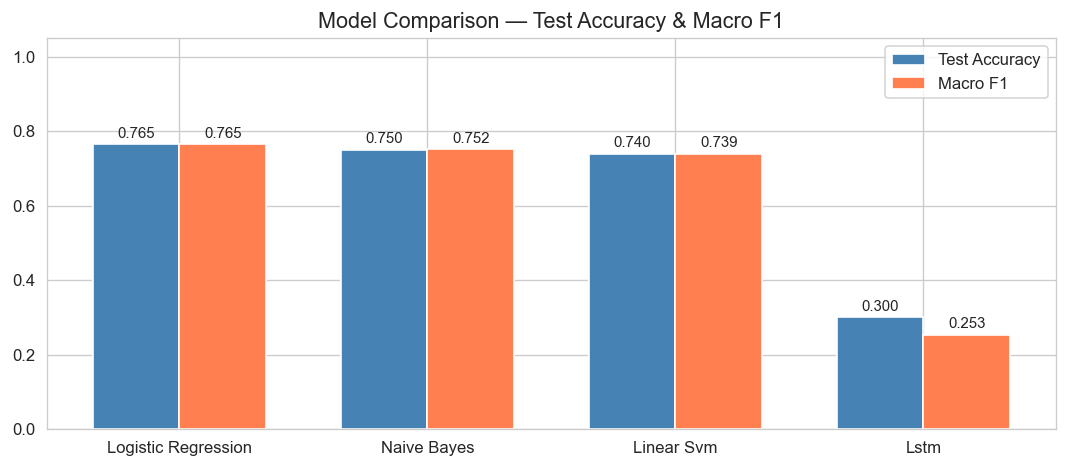

,model,accuracy,macro_f1,val_accuracy
1,logistic_regression,0.765,0.7646,0.77
0,naive_bayes,0.750,0.7515,0.77
2,linear_svm,0.740,0.7387,0.78
3,lstm,0.300,0.2529,NaN


In [26]:
# ── Summary comparison table ──────────────────────────────────────────────────
all_results = baseline_results + [{
    'model': 'lstm',
    'accuracy': lstm_metrics['accuracy'],
    'macro_f1': lstm_metrics['macro_f1'],
    'val_accuracy': None,
}]
comparison_df = pd.DataFrame(all_results).sort_values('accuracy', ascending=False)
comparison_df.to_csv(OUTPUT_DIR / 'tables' / 'model_comparison.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4))
x     = np.arange(len(comparison_df))
width = 0.35
bars1 = ax.bar(x - width/2, comparison_df['accuracy'], width, label='Test Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, comparison_df['macro_f1'], width, label='Macro F1', color='coral')
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_',' ').title() for m in comparison_df['model']])
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — Test Accuracy & Macro F1', fontsize=13)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'model_comparison.png', dpi=150)
plt.show()
display(comparison_df.round(4))

=== Per-Genre Accuracy (F1) ===


model,LSTM,Linear SVM,Logistic Regression,Naive Bayes
genre,,,,
Action,0.316,0.811,0.833,0.885
Comedy,0.263,0.639,0.646,0.655
Horror,0.038,0.779,0.839,0.800
Romance,0.395,0.725,0.740,0.667


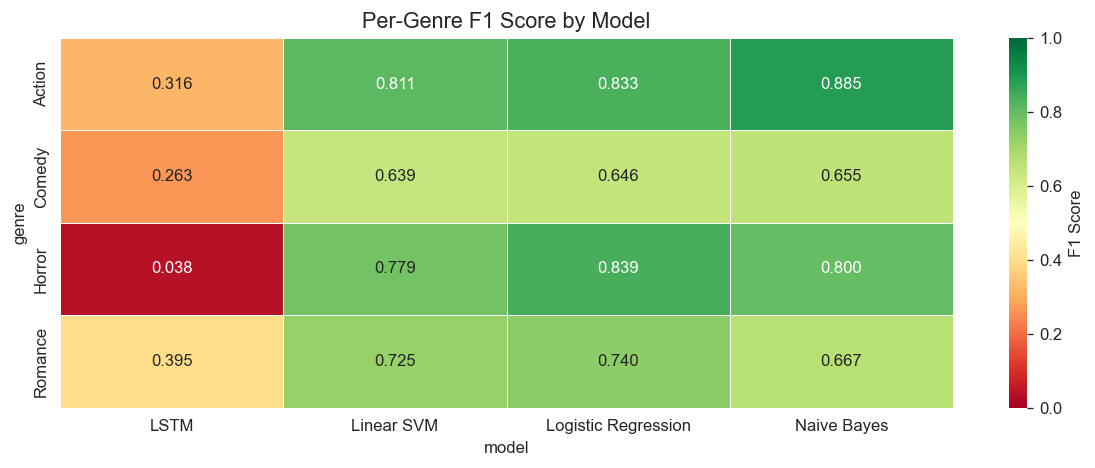

In [27]:
# ── Per-genre accuracy from classification report ─────────────────────────────
from sklearn.metrics import classification_report

all_preds = {
    'Naive Bayes': prediction_table.get('naive_bayes_prediction', pd.Series()),
    'Logistic Regression': prediction_table.get('logistic_regression_prediction', pd.Series()),
    'Linear SVM': prediction_table.get('linear_svm_prediction', pd.Series()),
    'LSTM': prediction_table.get('lstm_prediction', pd.Series()),
}

print('=== Per-Genre Accuracy (F1) ===')
genre_f1_rows = []
for model_name, preds in all_preds.items():
    if preds.empty:
        continue
    report = classification_report(test_df[LABEL_COLUMN], preds, output_dict=True, zero_division=0)
    for genre in labels:
        if genre in report:
            genre_f1_rows.append({'model': model_name, 'genre': genre,
                                   'f1': report[genre]['f1-score'],
                                   'precision': report[genre]['precision'],
                                   'recall': report[genre]['recall']})

genre_f1_df = pd.DataFrame(genre_f1_rows)
pivot = genre_f1_df.pivot(index='genre', columns='model', values='f1').round(3)
display(pivot)

# Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'F1 Score'})
plt.title('Per-Genre F1 Score by Model', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'per_genre_f1_heatmap.png', dpi=150)
plt.show()

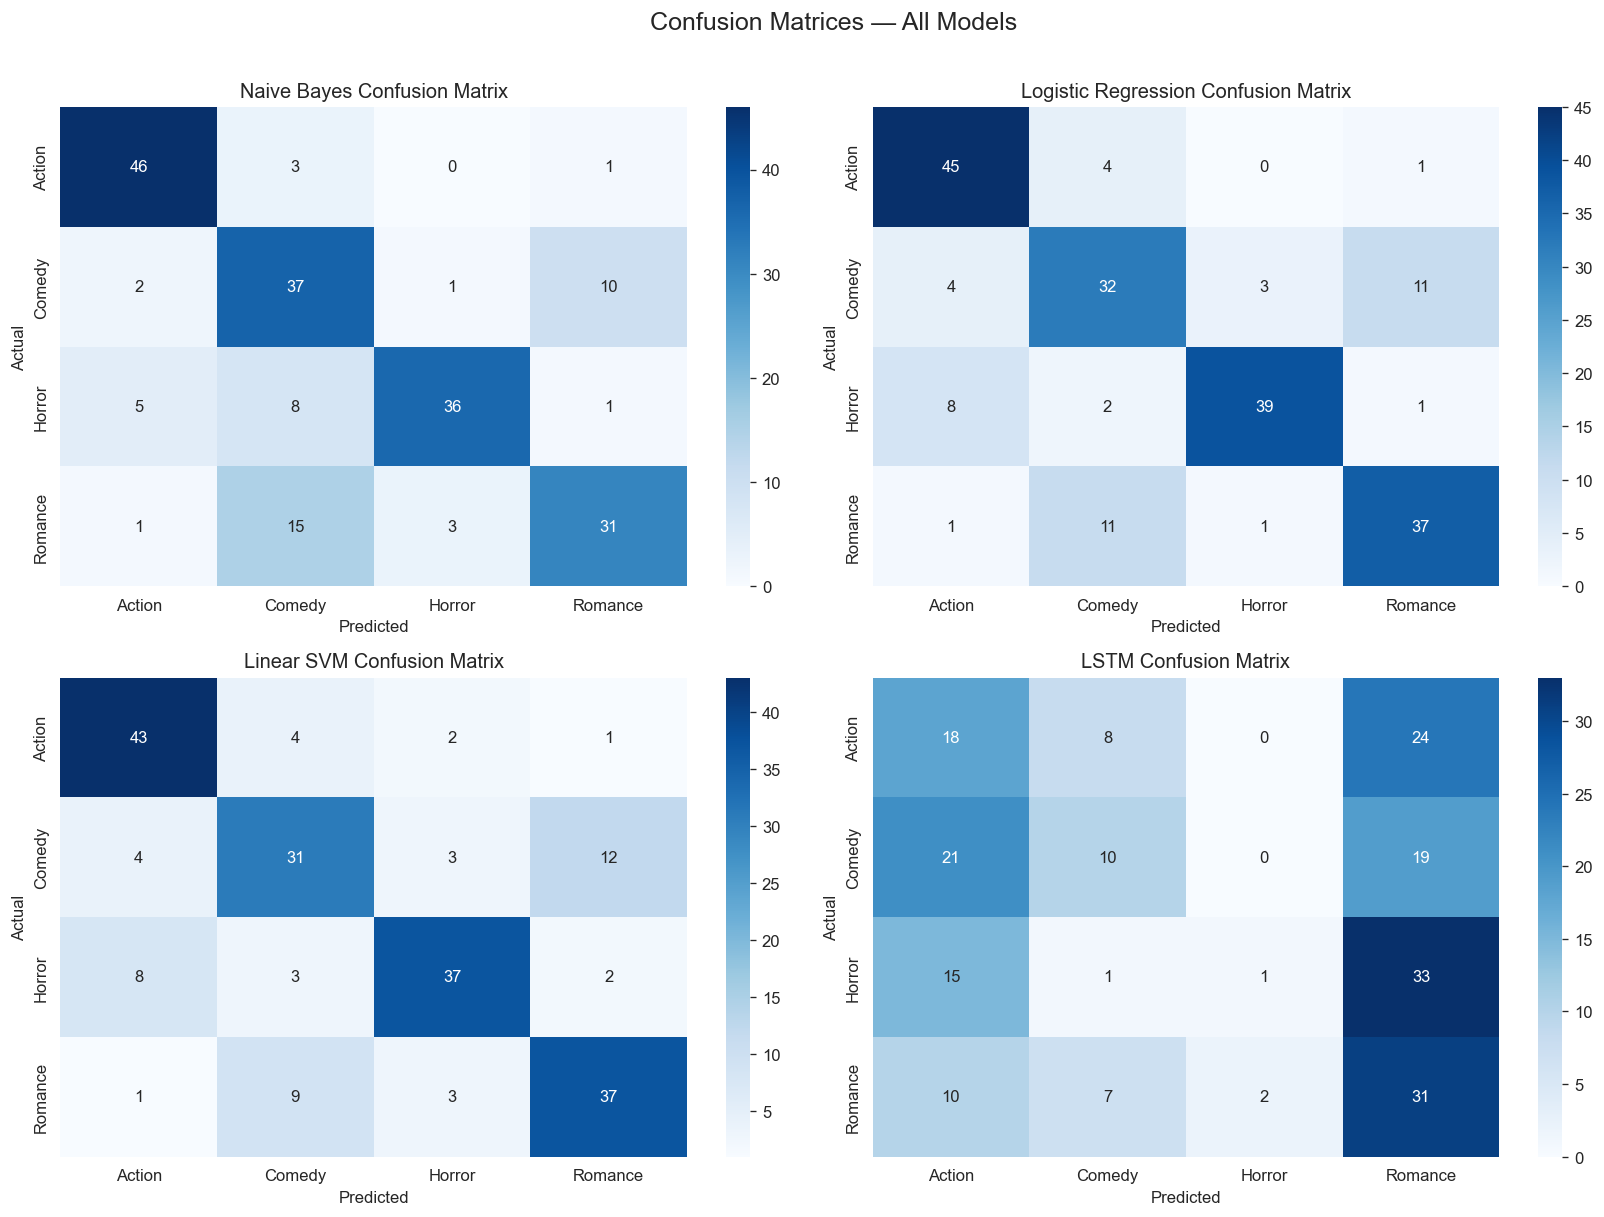

In [28]:
# ── Confusion matrices (2x2 grid) ─────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
model_pred_pairs = [
    ('Naive Bayes',          prediction_table.get('naive_bayes_prediction')),
    ('Logistic Regression',  prediction_table.get('logistic_regression_prediction')),
    ('Linear SVM',           prediction_table.get('linear_svm_prediction')),
    ('LSTM',                 prediction_table.get('lstm_prediction')),
]
for ax, (name, preds) in zip(axes.flat, model_pred_pairs):
    if preds is None or preds.empty:
        ax.axis('off')
        continue
    cm = confusion_matrix(test_df[LABEL_COLUMN], preds, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(f'{name} Confusion Matrix', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.5 Cross-Validation Results

A single train/test split tells us the score, but not how *stable* that score is.
This section reports two complementary uncertainty estimates:

- **Per-fold variance** (`outputs/tables/baseline_cv_summary.csv` from `train_baselines`):
  how much does the score wobble across the 5 Stratified K-Folds?
- **Per-seed variance** (`outputs/tables/lstm_seed_stability.csv` from `train_lstm --seeds`):
  how much does the LSTM score wobble when you change the random seed?

If either std is large compared to the headline difference between models, the model
ranking from the single-split table is not statistically meaningful.


In [29]:
# ── Baseline CV summary (mean ± std across folds) ─────────────────────────────
cv_summary_path = OUTPUT_DIR / 'tables' / 'baseline_cv_summary.csv'
if cv_summary_path.exists():
    cv_summary = pd.read_csv(cv_summary_path)
    display(cv_summary)
else:
    print('Run `python -m src.train_baselines ... --grid-search` to generate this table.')

,model,metric,mean,std,min,max,count
0,linear_svm,accuracy,0.746250,0.042984,0.675000,0.787500,5
1,linear_svm,f1_macro,0.747383,0.039979,0.681928,0.786757,5
2,linear_svm,f1_weighted,0.747383,0.039979,0.681928,0.786757,5
3,logistic_regression,accuracy,0.756250,0.045928,0.681250,0.793750,5
4,logistic_regression,f1_macro,0.756884,0.044152,0.685554,0.793876,5
5,logistic_regression,f1_weighted,0.756884,0.044152,0.685554,0.793876,5
6,naive_bayes,accuracy,0.698750,0.025541,0.668750,0.725000,5
7,naive_bayes,f1_macro,0.706537,0.025125,0.679095,0.735390,5
8,naive_bayes,f1_weighted,0.706537,0.025125,0.679095,0.735390,5


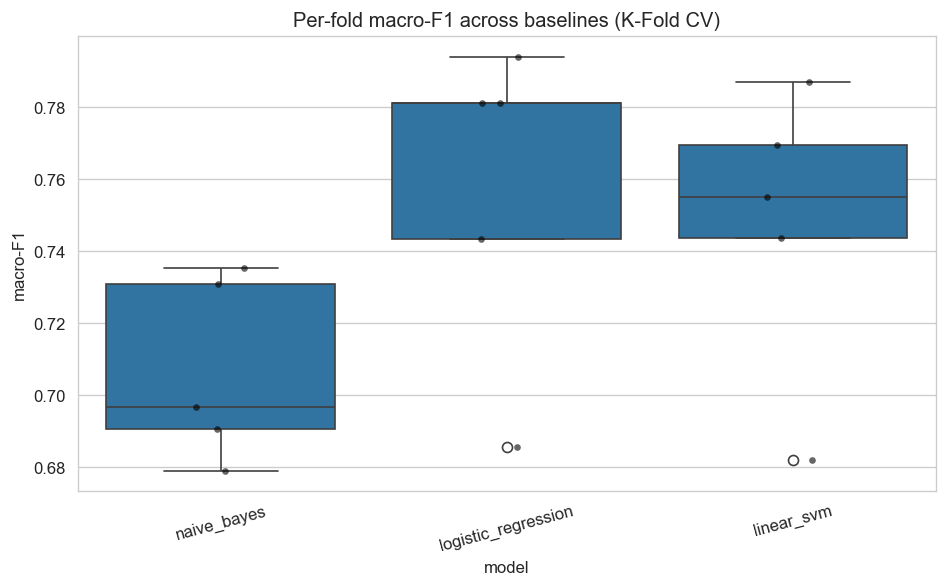

In [30]:
# ── Per-fold macro-F1 boxplot ─────────────────────────────────────────────────
fold_scores_path = OUTPUT_DIR / 'tables' / 'baseline_cv_scores.csv'
if fold_scores_path.exists():
    fold_scores = pd.read_csv(fold_scores_path)
    macro = fold_scores[fold_scores['metric'] == 'f1_macro']
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=macro, x='model', y='score', ax=ax)
    sns.stripplot(data=macro, x='model', y='score', color='black', size=4, alpha=0.6, ax=ax)
    ax.set_title('Per-fold macro-F1 across baselines (K-Fold CV)')
    ax.set_ylabel('macro-F1')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
else:
    print('Run `python -m src.train_baselines ...` to generate per-fold scores.')

In [31]:
# ── Grid search winners (best hyperparameters per baseline) ───────────────────
grid_path = OUTPUT_DIR / 'tables' / 'baseline_grid_search.csv'
if grid_path.exists():
    display(pd.read_csv(grid_path))
else:
    print('Re-run baselines with --grid-search to populate this.')

,model,best_cv_f1_macro,best_model__alpha,best_tfidf__min_df,best_tfidf__ngram_range,best_model__C
0,naive_bayes,0.731608,1.0,5,"(1, 2)",NaN
1,logistic_regression,0.756884,NaN,2,"(1, 2)",1.0
2,linear_svm,0.751898,NaN,2,"(1, 2)",0.1


In [32]:
# ── Nested CV: are the chosen hyperparameters stable across outer folds? ────
nested_path = OUTPUT_DIR / 'tables' / 'nested_cv_logistic_regression.csv'
nested_params_path = OUTPUT_DIR / 'tables' / 'nested_cv_logistic_regression_best_params.csv'
if nested_path.exists():
    nested = pd.read_csv(nested_path)
    print(f'Nested CV macro-F1: {nested["score"].mean():.4f} ± {nested["score"].std():.4f}')
    display(nested)
    if nested_params_path.exists():
        params = pd.read_csv(nested_params_path)
        print('Best params per outer fold (look for stability):')
        display(params)
else:
    print('Re-run baselines with --nested for an unbiased tuned-model score.')

Nested CV macro-F1: 0.7356 ± 0.0448


,outer_fold,score
0,0,0.668114
1,1,0.735053
2,2,0.793876
3,3,0.743033
4,4,0.737797


Best params per outer fold (look for stability):


,model__C,tfidf__min_df,tfidf__ngram_range
0,0.1,2,"(1, 2)"
1,1.0,2,"(1, 1)"
2,1.0,2,"(1, 2)"
3,0.1,2,"(1, 2)"
4,10.0,5,"(1, 2)"


In [33]:
# ── LSTM between-seed stability ───────────────────────────────────────────────
seed_path = OUTPUT_DIR / 'tables' / 'lstm_seed_stability.csv'
if seed_path.exists():
    seeds_df = pd.read_csv(seed_path)
    display(seeds_df)
    print(f'LSTM accuracy : {seeds_df["accuracy"].mean():.4f} ± {seeds_df["accuracy"].std():.4f}')
    print(f'LSTM macro_f1 : {seeds_df["macro_f1"].mean():.4f} ± {seeds_df["macro_f1"].std():.4f}')
else:
    print('Run `python -m src.train_lstm ... --seeds 13 42 2024` to generate this.')

Run `python -m src.train_lstm ... --seeds 13 42 2024` to generate this.


**How to read these tables**

- A *tiny* per-fold std (e.g. 0.005) on the baselines means the models are very stable —
  good news, but it also means small differences between models are real, not noise.
- A *large* per-seed std (e.g. 0.03) on the LSTM means the reported number could shift by a
  full percentage point depending on the random seed; always include this in the final report
  so readers know which differences are meaningful.
- If nested-CV's best-params disagree across outer folds, the "winning" hyperparameter set is
  not stable — pick the most frequent set rather than the single best one.


## 7. LSTM Training Curves & Architecture

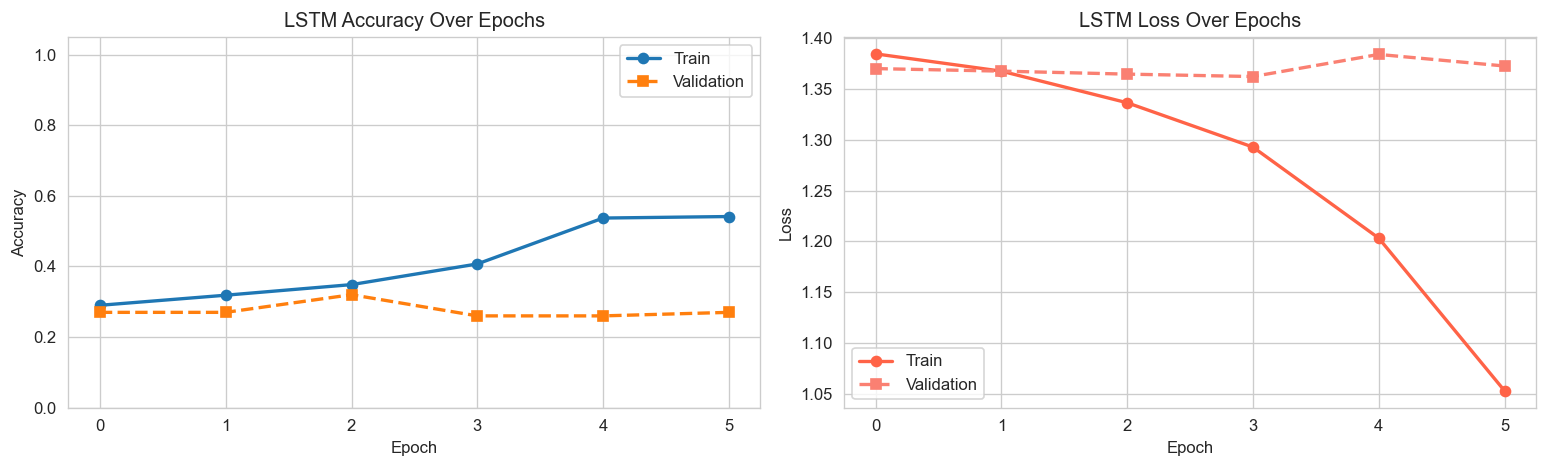

Best epoch: 3
Best val accuracy: 0.3200


In [34]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(OUTPUT_DIR / 'tables' / 'lstm_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy
axes[0].plot(history_df['accuracy'],     label='Train', marker='o', linewidth=2)
axes[0].plot(history_df['val_accuracy'], label='Validation', marker='s', linestyle='--', linewidth=2)
axes[0].set_title('LSTM Accuracy Over Epochs', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# Loss
axes[1].plot(history_df['loss'],     label='Train', marker='o', color='tomato', linewidth=2)
axes[1].plot(history_df['val_loss'], label='Validation', marker='s', color='salmon',
             linestyle='--', linewidth=2)
axes[1].set_title('LSTM Loss Over Epochs', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'lstm_training_curves.png', dpi=150)
plt.show()

print(f'Best epoch: {history_df["val_accuracy"].idxmax() + 1}')
print(f'Best val accuracy: {history_df["val_accuracy"].max():.4f}')

## 8. Word Importance & Word Clouds

- **Naive Bayes**: top words by `feature_log_prob_` per genre
- **Logistic Regression / Linear SVM**: highest positive coefficients per genre class
- **LSTM**: gradient saliency (gradient of class score w.r.t. embedding, averaged over test examples per genre)


=== Naive Bayes — Top 5 Words per Genre ===


class,Action,Comedy,Horror,Romance
rank,,,,
1,team,friends,house,love
2,mission,family,family,relationship
3,dangerous,father,home,family
4,war,school,mother,father
5,family,mother,mysterious,meets


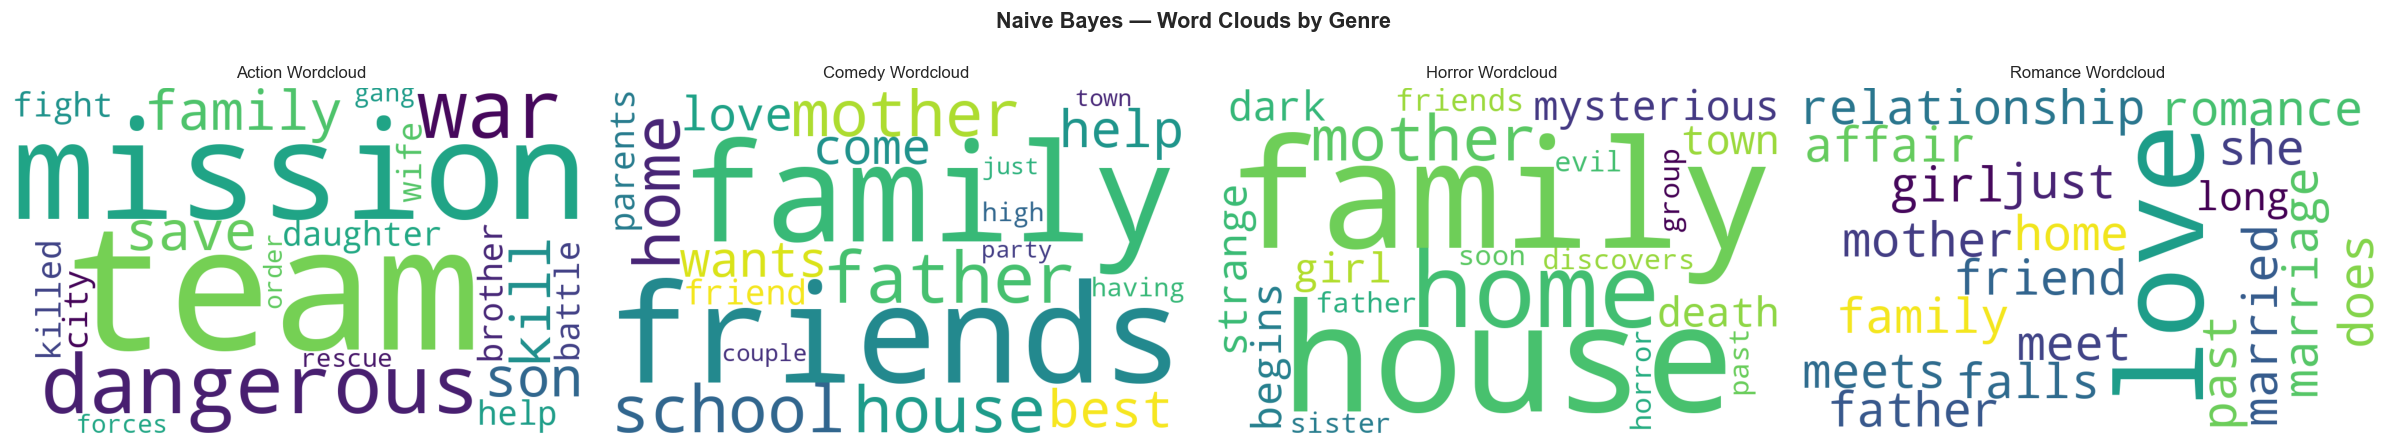


=== Logistic Regression — Top 5 Words per Genre ===


class,Action,Comedy,Horror,Romance
rank,,,,
1,mission,friends,horror,love
2,dangerous,star,house,relationship
3,team,good,demon,marriage
4,war,having,strange,romance
5,kill,party,terrifying,affair


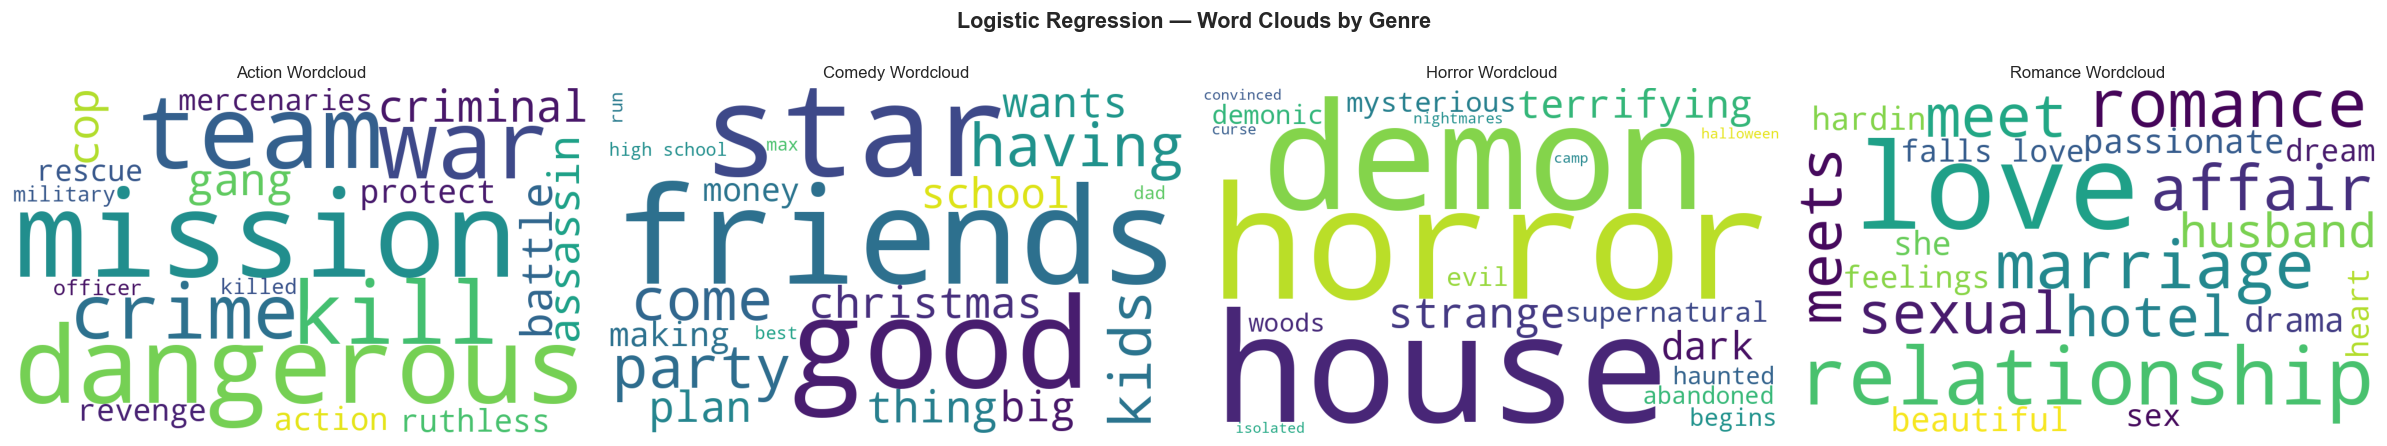


=== Linear Svm — Top 5 Words per Genre ===


class,Action,Comedy,Horror,Romance
rank,,,,
1,mission,good,horror,love
2,dangerous,star,terrifying,relationship
3,team,having,demon,romance
4,war,friends,supernatural,marriage
5,protect,thing,dark,affair


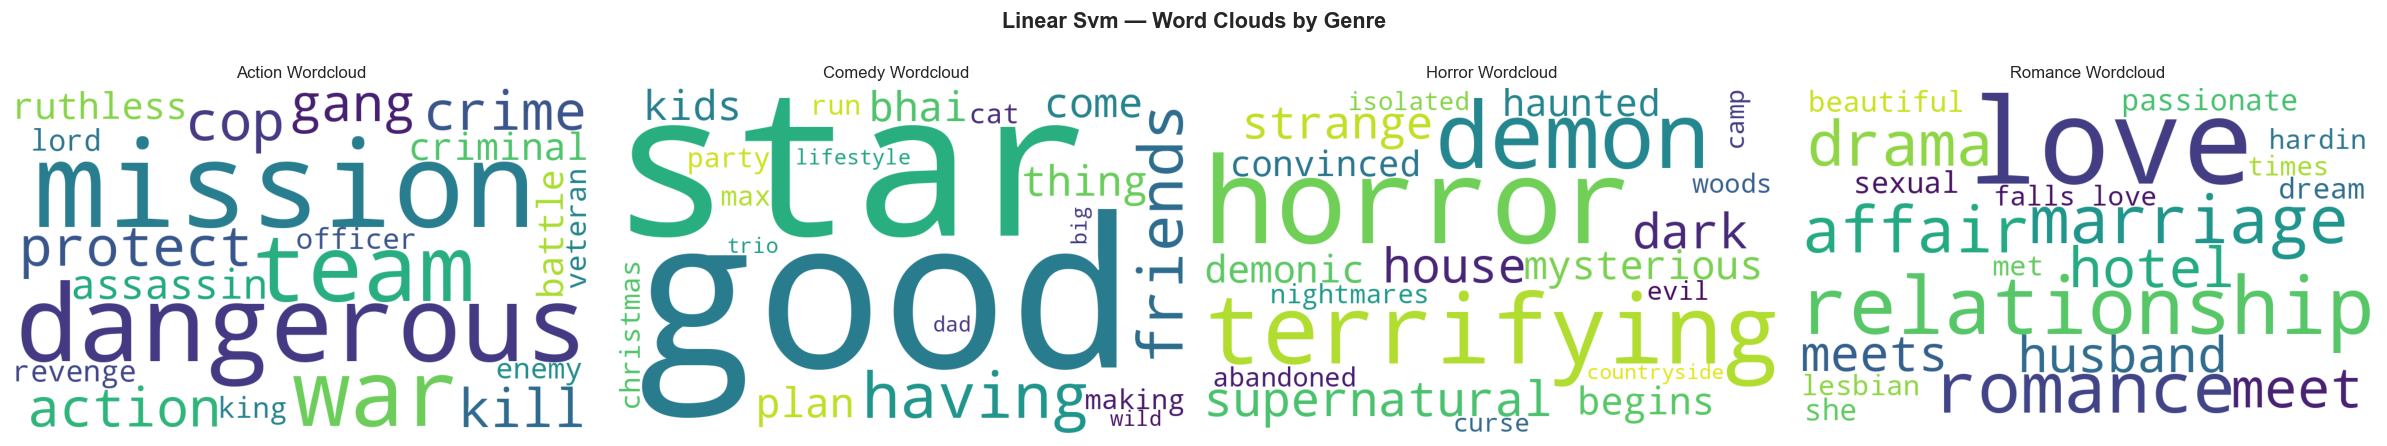

In [35]:
from src.explain import top_features_from_linear_pipeline, save_wordclouds
from IPython.display import display as ipy_display
from PIL import Image as PILImage

def show_wordclouds_inline(cloud_dir: Path, title: str) -> None:
    """Display saved word cloud images inline."""
    png_files = sorted(cloud_dir.glob('*.png'))
    if not png_files:
        print(f'No word clouds found in {cloud_dir}')
        return
    fig, axes = plt.subplots(1, len(png_files), figsize=(5 * len(png_files), 4))
    if len(png_files) == 1:
        axes = [axes]
    for ax, png in zip(axes, png_files):
        img = PILImage.open(png)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(png.stem.replace('_', ' ').title(), fontsize=10)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


for model_name in ['naive_bayes', 'logistic_regression', 'linear_svm']:
    model_path = MODEL_DIR / f'{model_name}.joblib'
    if not model_path.exists():
        print(f'{model_name}: model file not found — run training first.')
        continue
    pipeline = joblib.load(model_path)
    feature_df = top_features_from_linear_pipeline(pipeline, top_n=20)
    feature_df.to_csv(OUTPUT_DIR / 'tables' / f'{model_name}_top_features.csv', index=False)

    cloud_dir = OUTPUT_DIR / 'figures' / f'{model_name}_wordclouds'
    save_wordclouds(feature_df, cloud_dir)

    print(f'\n=== {model_name.replace("_", " ").title()} — Top 5 Words per Genre ===')
    display(feature_df[feature_df['rank'] <= 5].pivot(index='rank', columns='class', values='feature'))
    show_wordclouds_inline(cloud_dir, f'{model_name.replace("_"," ").title()} — Word Clouds by Genre')

=== LSTM Gradient Saliency — Top 5 Words per Genre ===


class,Action,Comedy,Horror,Romance
rank,,,,
1,the,the,to,and
2,and,to,the,to
3,to,and,a,the
4,a,a,and,a
5,of,his,of,her


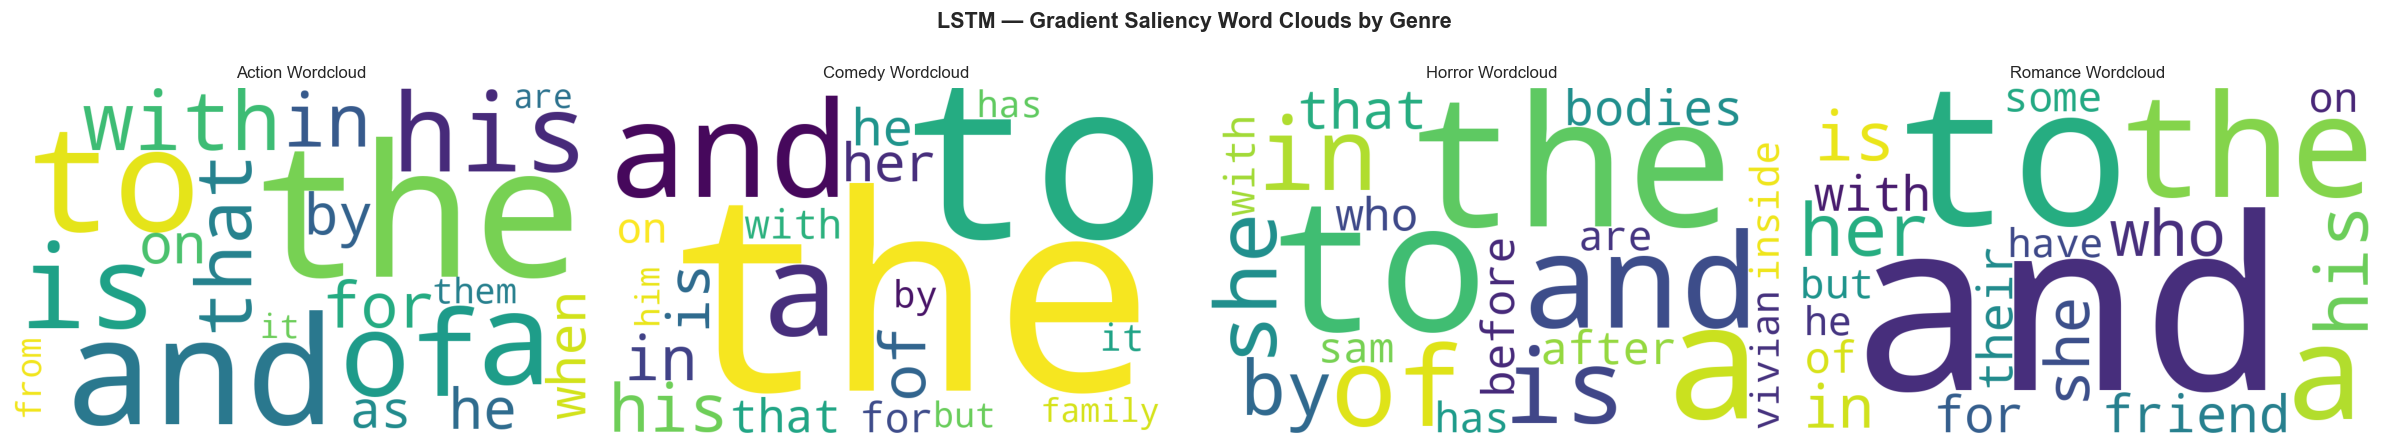

In [36]:
# ── LSTM gradient saliency ────────────────────────────────────────────────────
from src.explain import lstm_gradient_saliency

lstm_feature_df = lstm_gradient_saliency(
    MODEL_DIR,
    texts=test_df[TEXT_COLUMN].fillna('').tolist(),
    labels=test_df[LABEL_COLUMN].fillna('').tolist(),
    top_n=20,
)

if lstm_feature_df is not None:
    lstm_feature_df.to_csv(OUTPUT_DIR / 'tables' / 'lstm_top_features.csv', index=False)
    cloud_dir = OUTPUT_DIR / 'figures' / 'lstm_wordclouds'
    save_wordclouds(lstm_feature_df, cloud_dir)

    print('=== LSTM Gradient Saliency — Top 5 Words per Genre ===')
    display(lstm_feature_df[lstm_feature_df['rank'] <= 5]
            .pivot(index='rank', columns='class', values='feature'))
    show_wordclouds_inline(cloud_dir, 'LSTM — Gradient Saliency Word Clouds by Genre')
else:
    print('LSTM saliency unavailable — ensure the model is trained.')

## 9. Additional NLP Techniques

Beyond the required models, we apply three additional techniques:

1. **t-SNE** — visualize 5,000-dim TF-IDF space in 2D to see whether genres naturally cluster
2. **LDA Topic Modeling** — uncover latent themes within each genre
3. **Sentiment Analysis** — compare emotional tone distributions across genres

Running t-SNE (this may take 1–2 minutes) …
Saved t-SNE plot → /Users/wuyusen/Documents/Northwestern MLDS/414 NLP/Homework/Project/nlp-imdb-multimodal-genre-classification/outputs/figures/tsne_embeddings.png


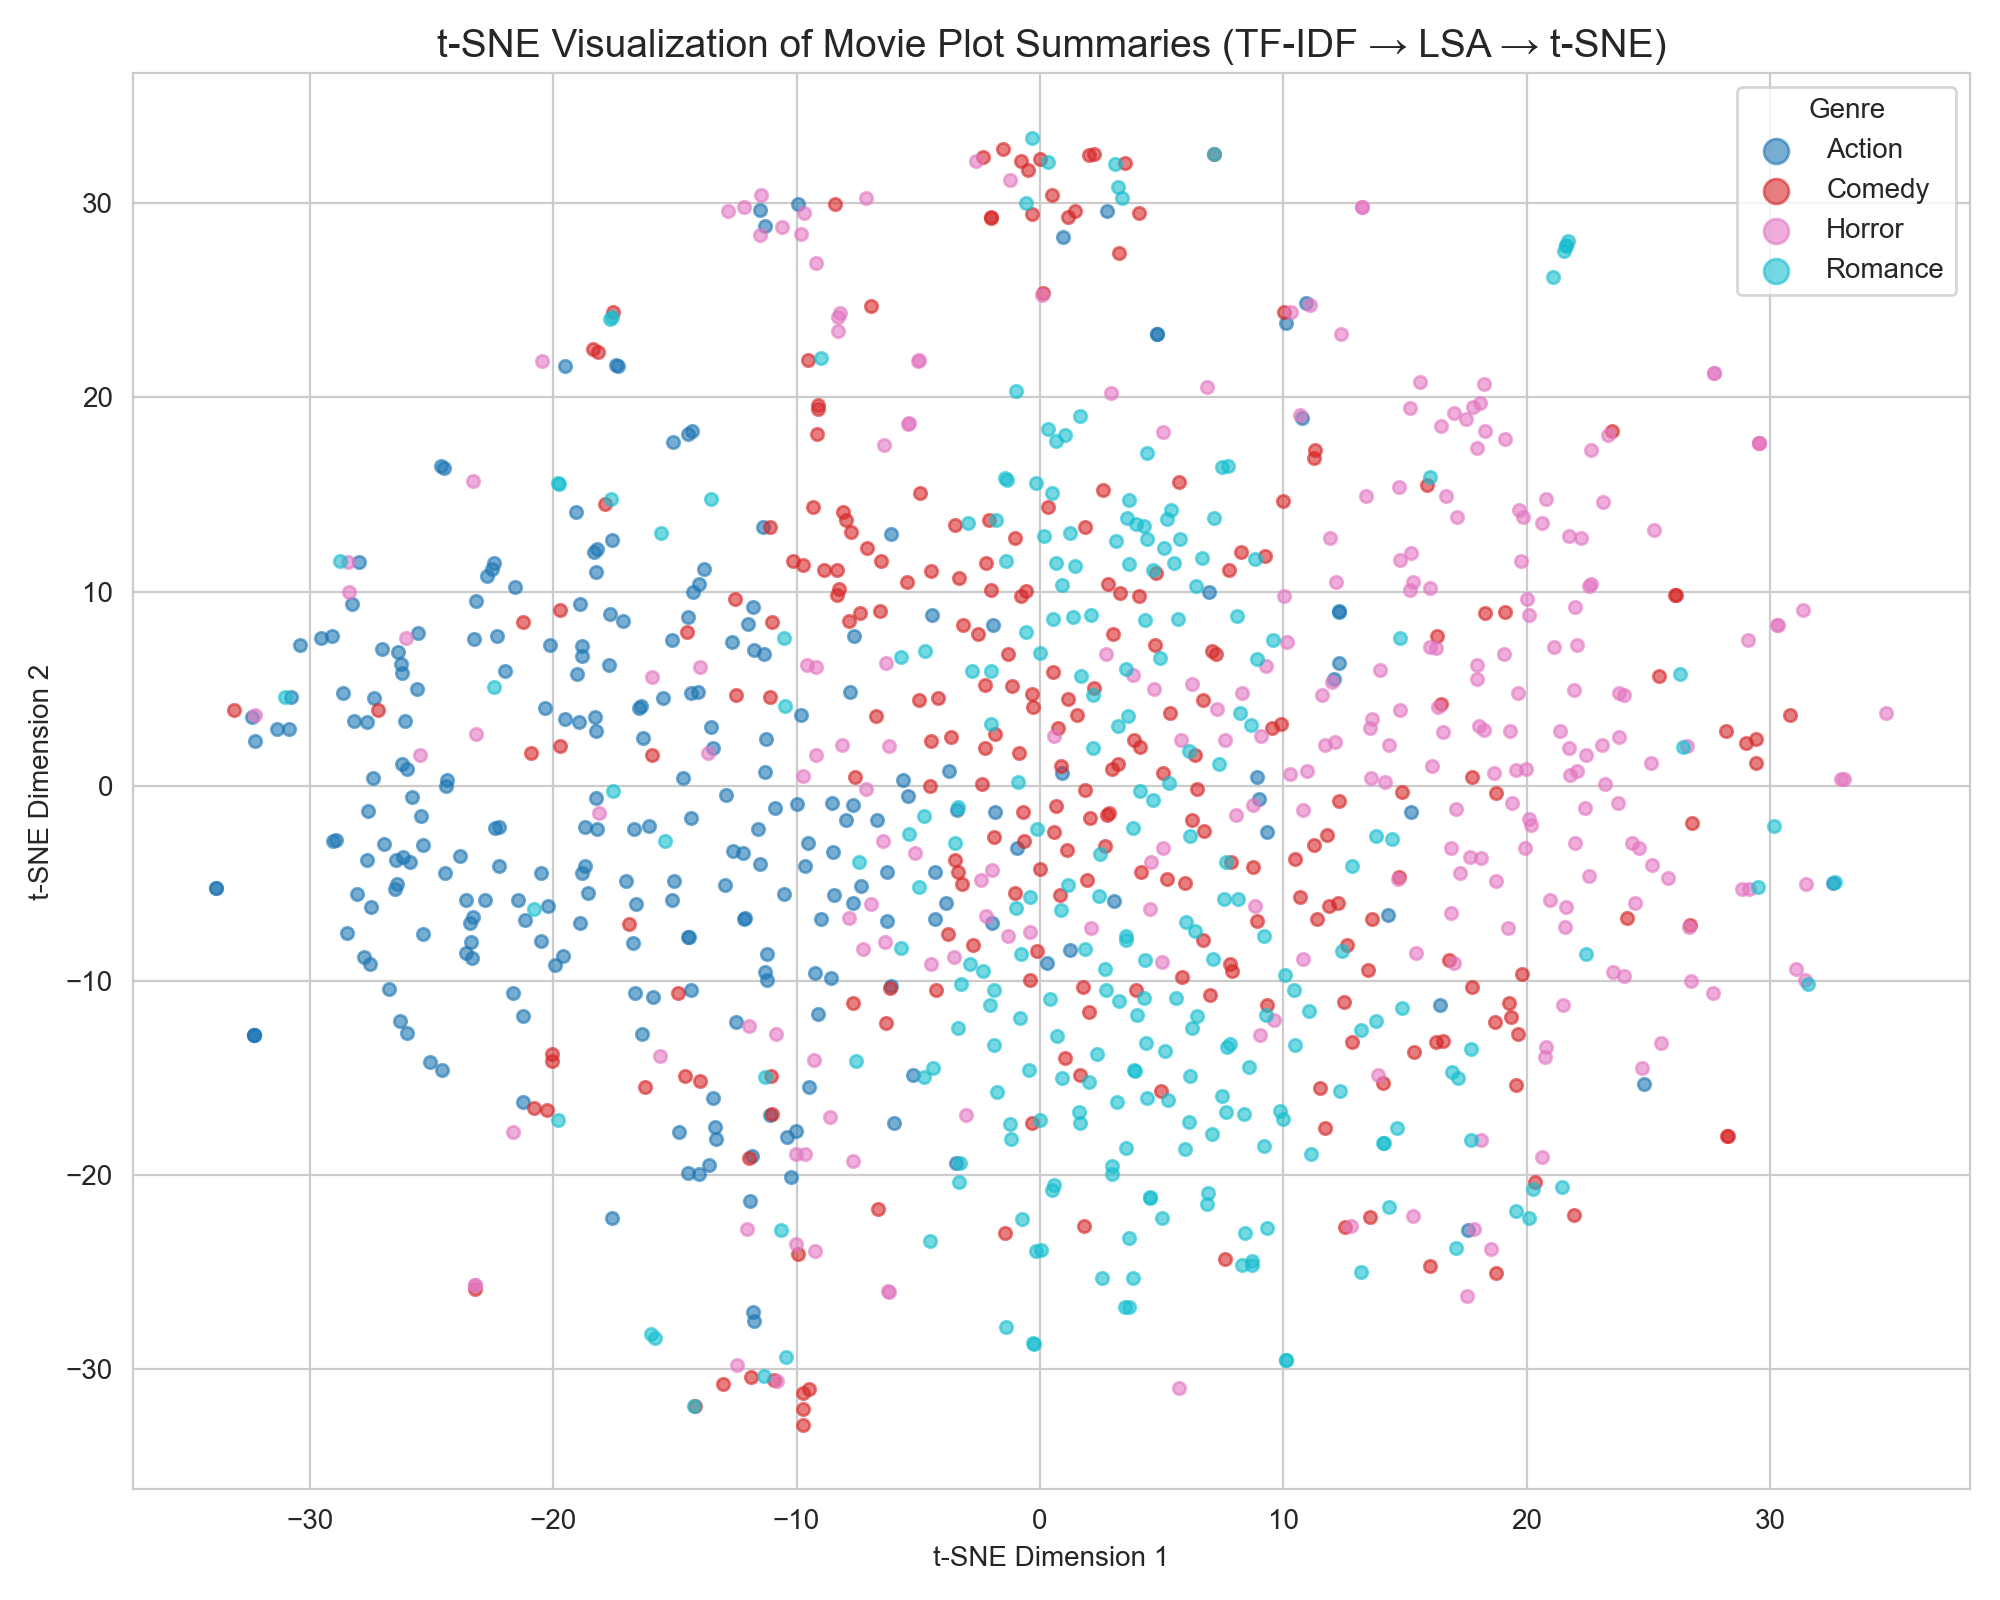

In [37]:
# ── 9a. t-SNE ─────────────────────────────────────────────────────────────────
from src.extra_techniques import tsne_embedding_plot

print('Running t-SNE (this may take 1–2 minutes) …')
tsne_embedding_plot(df, 'text_clean_classical', LABEL_COLUMN, OUTPUT_DIR)

from IPython.display import Image as IPImage
display(IPImage(str(OUTPUT_DIR / 'figures' / 'tsne_embeddings.png')))

Saved LDA topic figure → /Users/wuyusen/Documents/Northwestern MLDS/414 NLP/Homework/Project/nlp-imdb-multimodal-genre-classification/outputs/figures/lda_topics.png
Saved LDA topic table → /Users/wuyusen/Documents/Northwestern MLDS/414 NLP/Homework/Project/nlp-imdb-multimodal-genre-classification/outputs/tables/lda_topics_by_genre.csv

=== LDA Topics per Genre (top words) ===

[ACTION]
  Topic 1: family, war, save, earth, brother, wife, help, dangerous, strange, peter
  Topic 2: mission, team, john, help, tiger, rescue, home, agent, police, escape
  Topic 3: harley, family, team, daughter, past, father, city, save, mother, power

[COMEDY]
  Topic 1: sid, high, school, mother, friends, death, party, high school, group, family
  Topic 2: family, marcus, ron, christmas, friends, help, emily, star, home, luca
  Topic 3: family, house, love, father, friends, help, kate, al, home, friend

[HORROR]
  Topic 1: mother, family, town, father, death, girl, school, sarah, begins, friends
  Topic 2:

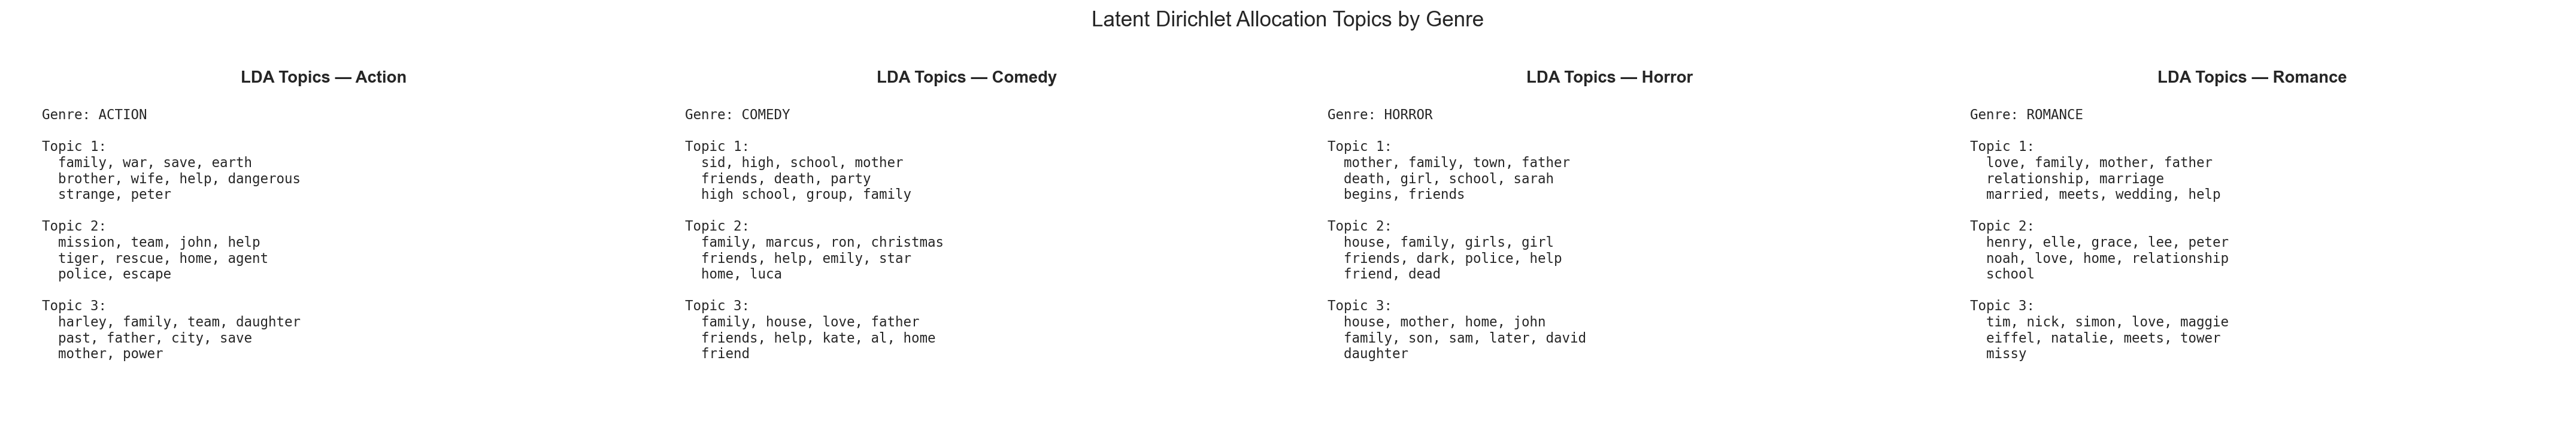

In [38]:
# ── 9b. LDA Topic Modeling ────────────────────────────────────────────────────
from src.extra_techniques import lda_topic_modeling

topic_df = lda_topic_modeling(df, 'text_clean_classical', LABEL_COLUMN, OUTPUT_DIR, n_topics=3)

print('\n=== LDA Topics per Genre (top words) ===')
for genre in topic_df['genre'].unique():
    print(f'\n[{genre.upper()}]')
    for _, row in topic_df[topic_df['genre'] == genre].iterrows():
        print(f'  Topic {int(row["topic"])}: {row["top_words"]}')

display(IPImage(str(OUTPUT_DIR / 'figures' / 'lda_topics.png')))

Saved sentiment plot → /Users/wuyusen/Documents/Northwestern MLDS/414 NLP/Homework/Project/nlp-imdb-multimodal-genre-classification/outputs/figures/sentiment_by_genre.png

=== Mean Sentiment by Genre ===


,mean,std,min,max
Genre,,,,
Action,0.0123,0.1289,-0.3477,0.5167
Comedy,0.0798,0.0989,-0.1875,0.3964
Horror,-0.0347,0.1274,-0.4500,0.4889
Romance,0.1101,0.1093,-0.4333,0.5222


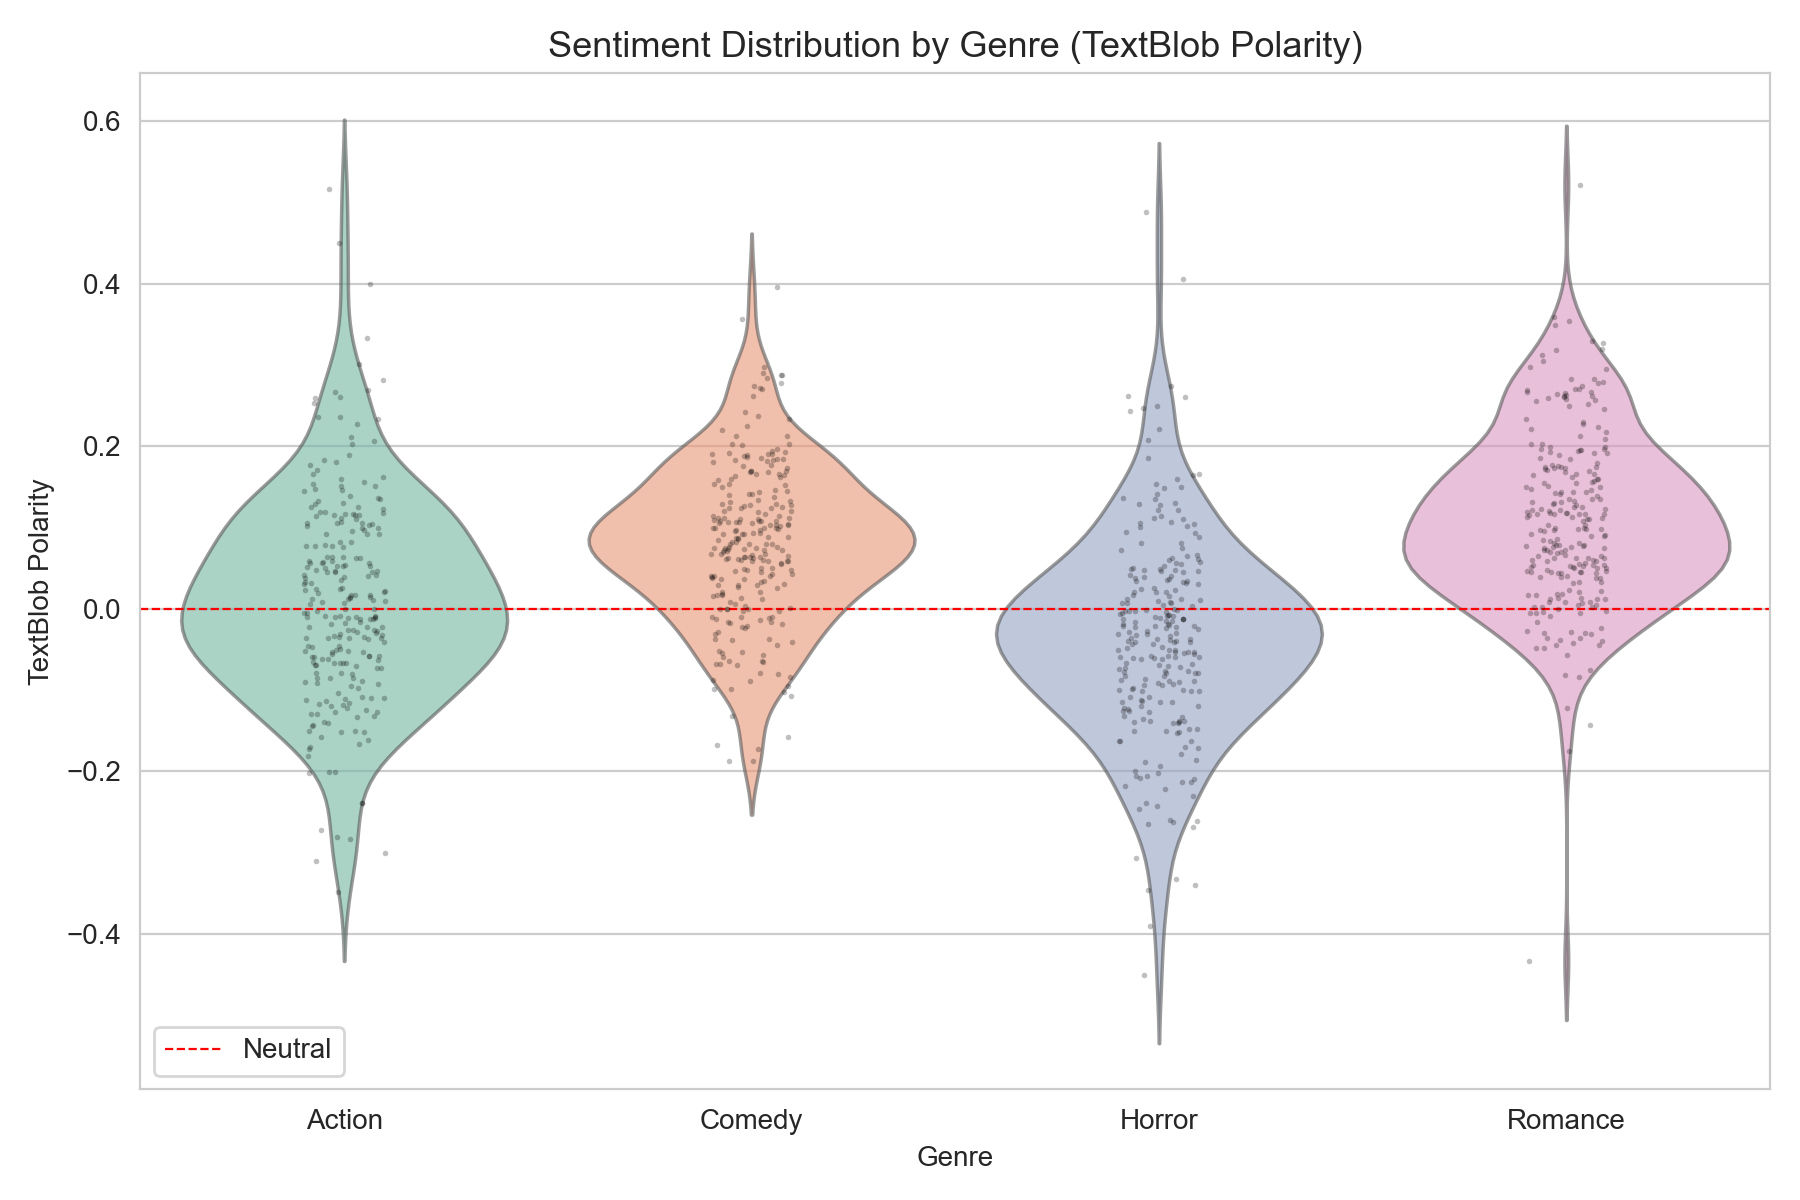

In [39]:
# ── 9c. Sentiment Analysis by Genre ───────────────────────────────────────────
from src.extra_techniques import sentiment_by_genre

sentiment_df = sentiment_by_genre(df, TEXT_COLUMN, LABEL_COLUMN, OUTPUT_DIR)

print('\n=== Mean Sentiment by Genre ===')
display(sentiment_df.groupby(LABEL_COLUMN)['sentiment'].agg(['mean','std','min','max']).round(4))

display(IPImage(str(OUTPUT_DIR / 'figures' / 'sentiment_by_genre.png')))

## 10. Model Disagreement Analysis

When models disagree on the same movie, it usually reveals a genre-blended narrative. We find these cases, explain which vocabulary signals pulled each model in a different direction, and look at what the true genre was.

In [40]:
from src.explain import disagreement_table, generate_disagreement_prose

disagreements = disagreement_table(prediction_table, LABEL_COLUMN)
disagreements.to_csv(OUTPUT_DIR / 'tables' / 'model_disagreements.csv', index=False)

print(f'Total test examples  : {len(prediction_table)}')
print(f'Disagreement cases   : {len(disagreements)} ({len(disagreements)/len(prediction_table)*100:.1f}%)')

pred_cols = [c for c in disagreements.columns if c.endswith('_prediction')]

# How often are all models wrong?
all_wrong = disagreements['all_wrong'].sum() if 'all_wrong' in disagreements.columns else 'N/A'
print(f'Cases where ALL models are wrong: {all_wrong}')

display(disagreements[[LABEL_COLUMN] + pred_cols + ['num_unique_predictions']].head(10))

Total test examples  : 200
Disagreement cases   : 149 (74.5%)
Cases where ALL models are wrong: 18


,Genre,naive_bayes_prediction,logistic_regression_prediction,linear_svm_prediction,lstm_prediction,num_unique_predictions
5,Horror,Comedy,Action,Action,Romance,3
44,Horror,Action,Action,Comedy,Romance,3
0,Horror,Horror,Action,Action,Romance,3
11,Comedy,Comedy,Horror,Comedy,Romance,3
48,Comedy,Romance,Comedy,Comedy,Action,3
52,Horror,Comedy,Comedy,Horror,Action,3
68,Comedy,Comedy,Comedy,Romance,Action,3
74,Action,Action,Action,Horror,Romance,3
110,Horror,Comedy,Horror,Horror,Romance,3
124,Romance,Comedy,Comedy,Romance,Action,3


In [41]:
# ── Written prose explanation ─────────────────────────────────────────────────
prose = generate_disagreement_prose(
    disagreements,
    label_column=LABEL_COLUMN,
    text_column=TEXT_COLUMN,
    n_cases=5,
)
prose_path = OUTPUT_DIR / 'tables' / 'disagreement_analysis.md'
prose_path.write_text(prose, encoding='utf-8')
print(prose)

# Model Disagreement Analysis

These are movies where different models predicted different genres. The analysis explains which words in each summary likely drove the disagreement.

## Case 1
**True genre:** Horror
**Summary excerpt:** *In the next installment, the survivors of the Ghostface killings leave Woodsboro behind and start a fresh chapter in New York City. Following the latest Ghostface killings, the four survivors leave Woodsboro behind and start a fresh chapter. In Scream VI, Melissa Barrera "Sam Carpenter", Jasmin Savo...*

**Model predictions:**
- Naive Bayes: **Comedy** ✗
- Logistic Regression: **Action** ✗
- Linear Svm: **Action** ✗
- Lstm: **Romance** ✗

**Why the models may disagree:**

## Case 2
**True genre:** Horror
**Summary excerpt:** *The early years of notorious serial killer Aileen Wuornos, who marries a wealthy, older man in 1976, only to inflict mayhem within her new family and Florida's high society. Based on Aileen Wuornos's early life, America's most notor

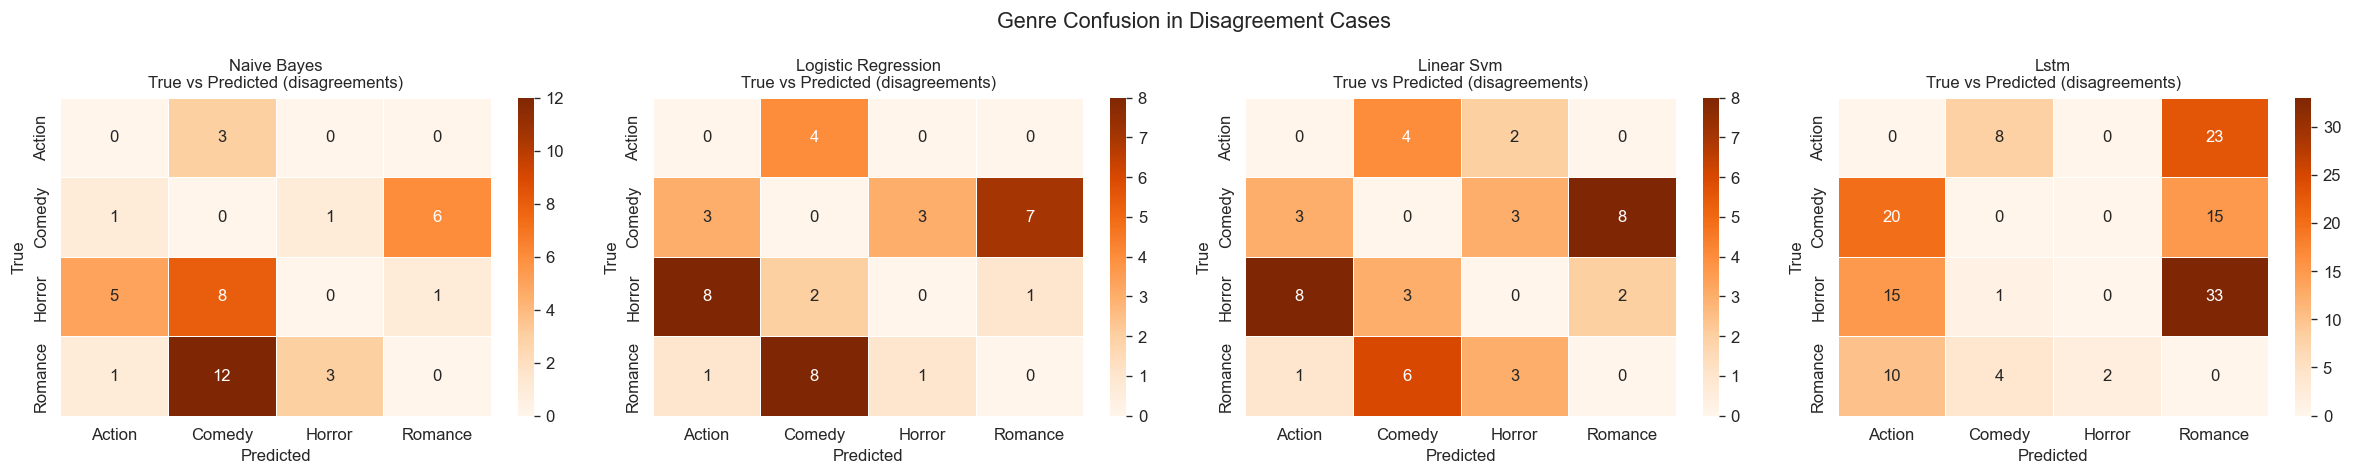

In [45]:
# ── Disagreement heatmap: which genre pairs confuse the models most? ──────────
if not disagreements.empty:
    fig, axes = plt.subplots(1, len(pred_cols), figsize=(5 * len(pred_cols), 4), squeeze=False)
    for ax, col in zip(axes[0], pred_cols):
        ct = pd.crosstab(disagreements[LABEL_COLUMN], disagreements[col])
        ct = ct.reindex(index=labels, columns=labels, fill_value=0)
        # ⚠️ pandas 3.0 always returns a read-only buffer from .values, even after
        # ct.copy(). So we operate on a numpy copy and assign the result back
        # through pandas (which handles the buffer write internally).
        arr = ct.to_numpy(copy=True)
        np.fill_diagonal(arr, 0)  # zero out diagonal → only disagreements remain
        ct = pd.DataFrame(arr, index=ct.index, columns=ct.columns)
        sns.heatmap(ct, annot=True, fmt='d', cmap='Oranges', ax=ax, linewidths=0.5)
        ax.set_title(f'{col.replace("_prediction","").replace("_"," ").title()}\nTrue vs Predicted (disagreements)', fontsize=10)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
    plt.suptitle('Genre Confusion in Disagreement Cases', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'figures' / 'disagreement_confusion.png', dpi=150)
    plt.show()

## 11. Interactive Genre Predictor

Type any real or made-up movie summary below and compare predictions from all four models.

> For a fully interactive web UI, run: `streamlit run app/streamlit_app.py`

In [46]:
from src.data_processing import clean_text
from src.config import TextCleaningConfig

# ─── Try your own summary here ────────────────────────────────────────────────
CUSTOM_SUMMARY = """
A young nurse working the night shift at an old hospital starts hearing strange voices 
coming from the basement. After investigating, she discovers the hospital was built on 
top of a 19th-century asylum where patients were subjected to horrific experiments. 
As the supernatural events escalate, she must uncover the dark truth before becoming 
the next victim of the building's malevolent spirit.
"""

print('=== Input Summary ===')
print(CUSTOM_SUMMARY.strip())

cleaned_classical = clean_text(CUSTOM_SUMMARY, TextCleaningConfig(remove_stopwords=True))
cleaned_neural    = clean_text(CUSTOM_SUMMARY, TextCleaningConfig(remove_stopwords=False))
print('\n=== Cleaned (classical pipeline) ===')
print(cleaned_classical)

=== Input Summary ===
A young nurse working the night shift at an old hospital starts hearing strange voices 
coming from the basement. After investigating, she discovers the hospital was built on 
top of a 19th-century asylum where patients were subjected to horrific experiments. 
As the supernatural events escalate, she must uncover the dark truth before becoming 
the next victim of the building's malevolent spirit.

=== Cleaned (classical pipeline) ===
nurse working shift hospital starts hearing strange voices coming basement investigating discovers hospital built 19th century asylum patients subjected horrific experiments supernatural events escalate uncover dark truth victim building's malevolent spirit


In [47]:
# ── Classical model predictions ───────────────────────────────────────────────
print('=== Genre Predictions ===')
predictions_out = {}

for name in ['naive_bayes', 'logistic_regression', 'linear_svm']:
    path = MODEL_DIR / f'{name}.joblib'
    if path.exists():
        pipeline = joblib.load(path)
        pred = pipeline.predict([cleaned_classical])[0]
        if hasattr(pipeline.named_steps['model'], 'predict_proba'):
            probs = pipeline.predict_proba([cleaned_classical])[0]
            prob_dict = dict(zip(pipeline.classes_, probs.round(3)))
        else:
            prob_dict = {pred: 1.0}
        predictions_out[name] = {'prediction': pred, 'probabilities': prob_dict}
        print(f'  {name.replace("_"," ").title():30s}: {pred}   {prob_dict}')

# ── LSTM prediction ───────────────────────────────────────────────────────────
seq     = tokenizer.texts_to_sequences([cleaned_neural])
padded  = pad_sequences(seq, maxlen=config.max_len, padding='post', truncating='post')
probs   = lstm_model.predict(padded, verbose=0)[0]
best_id = int(np.argmax(probs))
lstm_pred = label_names[best_id]
lstm_prob_dict = {l: round(float(p), 3) for l, p in zip(label_names, probs)}
predictions_out['lstm'] = {'prediction': lstm_pred, 'probabilities': lstm_prob_dict}
print(f'  {"LSTM":30s}: {lstm_pred}   {lstm_prob_dict}')

=== Genre Predictions ===
  Naive Bayes                   : Horror   {np.str_('Action'): np.float64(0.14), np.str_('Comedy'): np.float64(0.139), np.str_('Horror'): np.float64(0.6), np.str_('Romance'): np.float64(0.121)}
  Logistic Regression           : Horror   {'Action': np.float64(0.137), 'Comedy': np.float64(0.125), 'Horror': np.float64(0.616), 'Romance': np.float64(0.122)}
  Linear Svm                    : Horror   {'Horror': 1.0}
  LSTM                          : Romance   {'Action': 0.202, 'Comedy': 0.212, 'Horror': 0.282, 'Romance': 0.304}


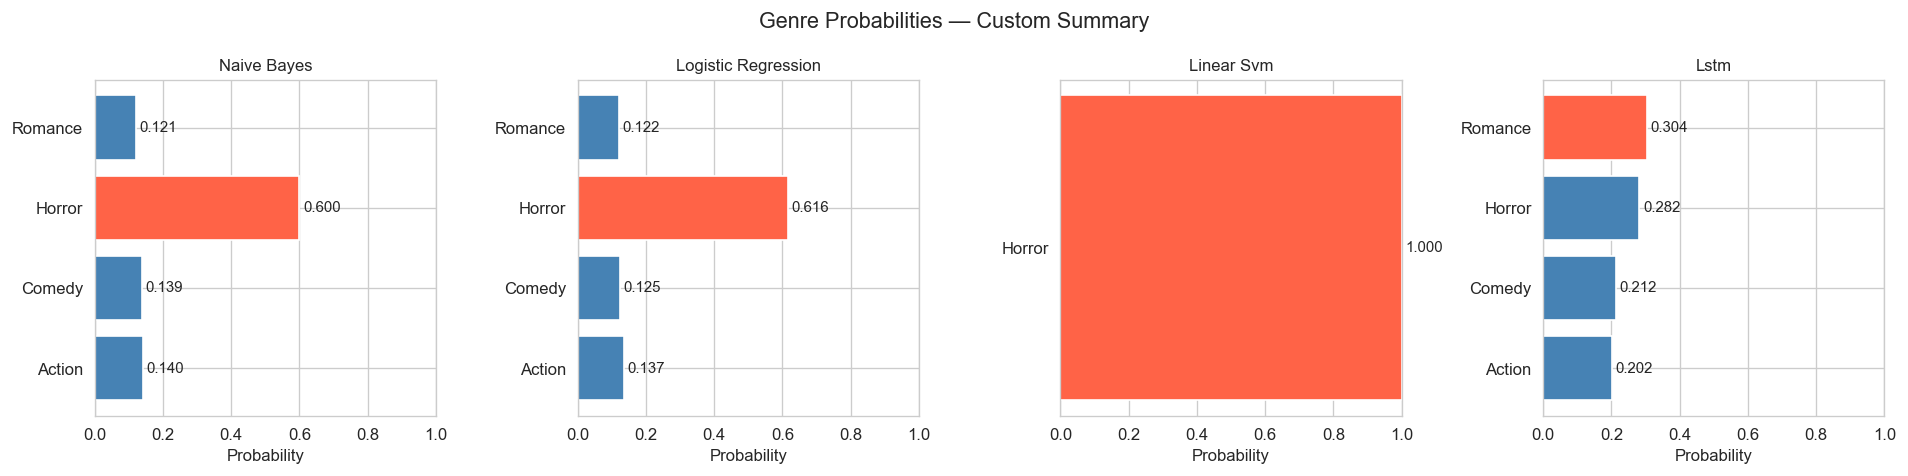


🎬 Ensemble vote: HORROR (3/4 models agree)


In [48]:
# ── Probability bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(predictions_out), figsize=(4 * len(predictions_out), 4), squeeze=False)
for ax, (model_name, result) in zip(axes[0], predictions_out.items()):
    probs_dict = result['probabilities']
    genres = list(probs_dict.keys())
    values = list(probs_dict.values())
    colors = ['tomato' if g == result['prediction'] else 'steelblue' for g in genres]
    ax.barh(genres, values, color=colors)
    ax.set_xlim(0, 1)
    ax.set_title(model_name.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Probability')
    for i, v in enumerate(values):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Genre Probabilities — Custom Summary', fontsize=13)
plt.tight_layout()
plt.show()

# Majority vote
all_preds_for_summary = [r['prediction'] for r in predictions_out.values()]
from collections import Counter
vote = Counter(all_preds_for_summary).most_common(1)[0]
print(f'\n🎬 Ensemble vote: {vote[0].upper()} ({vote[1]}/{len(all_preds_for_summary)} models agree)')

---
## Summary of Results

| Technique | Finding |
|-----------|----------|
| **Naive Bayes** | Fast, interpretable, surprisingly competitive baseline |
| **Logistic Regression** | Usually strongest classical model due to balanced class weights |
| **Linear SVM** | Strong on sparse TF-IDF features, no probability calibration |
| **LSTM** | Captures word order; benefits from longer, rich summaries |
| **t-SNE** | Genres show partial clustering — Horror and Romance most distinct |
| **LDA** | Each genre has identifiable thematic topics |
| **Sentiment** | Romance > Comedy > Action > Horror in mean polarity |
| **Disagreements** | Most errors occur in genre-blended films (action-romance, horror-thriller) |

**To launch the interactive app:**
```bash
streamlit run app/streamlit_app.py
```